In [13]:
%run _bootstrap_dev.ipynb


Runtime dev completato.


In [14]:
# # smoke test imports
# from r_functions import run_wfo_pipeline, analyze_portfolio_metrics
# from u_functions import my_display, Emoji, BOLD, RESET, DIM
# print("Import critici OK")
# import kaleido
# print(kaleido.__version__)

## §2 — Portafoglio da analizzare

In [15]:
#
# Quale portafoglio analizzare
#
# portfolio = portfolio_alpha_euro
# portfolio = portfolio_alpha_sect
# portfolio = portfolio_alpha_world
# portfolio = portfolio_alpha_world_vanguard
portfolio = portfolio_alpha_nasdaq100
# portfolio = portfolio_alpha_sp100
# portfolio = portfolio_germany_plan
# portfolio = portfolio_italy_big_cap
# portfolio = portfolio_alpha_quant # New Ema
# portfolio = portfolio_alpha_fact

# Profile di destinazione del PTF nel portafoglio del cliente
# Determina le soglie di overfitting check (S1-S4).
# "satellite": quota tattica, cerca alpha; "core": quota di base, prioritizza capital preservation.
profile = "satellite"   # "satellite" | "core"

# --- Derivazione automatica dalle proprieta' del portfolio ---
# Flag calcolato PRIMA della risoluzione Wikipedia, quando tickers è ancora stringa.
survivorship_bias_universe = isinstance(portfolio['tickers'], str)
tickers = portfolio['tickers']
tickers = (
    extract_tickers_from_wikipedia(tickers, exclude=["GOOG"], rename={"BRK.B": "BRK-B"})
    if isinstance(tickers, str)
    else list(tickers)
)
benchmark_portfolio = portfolio['benchmark_portfolio']
benchmark_title     = portfolio['benchmark_title']
portfolio_title     = portfolio['Title']

# Percorso file WFO
wfo_results_dir = _TSLAB_DEV_R_WFO_RESULTS_DIR
wfo_file_save   = f"{wfo_results_dir}/{portfolio_title}_{year}.wfo_summary.csv"

# Date di analisi
start_date = "2015-01-01"
end_date   = None          # None = oggi
year       = 2026          # anno di selezione corrente

print(f"Portafoglio: {BOLD}{portfolio_title}{RESET}  |  Profile: {BOLD}{profile}{RESET}")
print(f"Ticker: {len(tickers)}  |  Benchmark: {benchmark_title}")
print(f"WFO file: {wfo_file_save}")
print(f"Survivorship bias universe: {survivorship_bias_universe}")

reports_dir = get_analysis_output_dir("r_analysis", ptf_name=portfolio_title.replace(' ', '_').lower())
plots_dir   = reports_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
print(f"reports_dir: {reports_dir}")
print(f"plots_dir: {plots_dir}")

Portafoglio: Alpha Nasdaq100  |  Profile: satellite
Ticker: 100  |  Benchmark: CSNDX.MI
WFO file: ../../outputs/WFO_R_DEV_RESULTS/Alpha Nasdaq100_2026.wfo_summary.csv
Survivorship bias universe: True
reports_dir: ../../outputs/r_analysis/alpha_nasdaq100/20260626_160201
plots_dir: ../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/plots


## §3 — Download data

In [16]:
init_cash      = 100_000
normalize      = False    # lasciare False nei rotazionali: NaN = titolo assente
lookback_buffer = 365

download_start_date = (pd.to_datetime(start_date) - timedelta(days=lookback_buffer)).strftime("%Y-%m-%d")

stocks_data, company_data = fetch_data_and_companies(
    tickers, download_start_date, end_date, normalize=normalize
)
stocks_data_raw = download_data(tickers, download_start_date, end_date, auto_adjust=False)

# Usato dalla Stability Analysis 
portfolio["stocks_data"] = stocks_data
portfolio["init_cash"]   = init_cash

if benchmark_portfolio:
    benchmark_data     = build_benchmark(benchmark_portfolio,
                             stocks_data.index.min(), stocks_data.index.max()).replace(0, np.nan).ffill()
    benchmark_data_raw = build_benchmark(benchmark_portfolio,
                             stocks_data.index.min(), stocks_data.index.max(),
                             auto_adjust=False).replace(0, np.nan).ffill()
elif benchmark_title:
    benchmark_data     = download_data(benchmark_title, stocks_data.index.min(), end_date)
    benchmark_data_raw = download_data(benchmark_title, stocks_data_raw.index.min(), end_date,
                                       auto_adjust=False)
else:
    benchmark_data = benchmark_data_raw = None

display(stocks_data)

Ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-02,17.124882,NaN,59.290001,38.030693,53.050735,49.250000,29.571953,63.860001,14.973543,3.950000,...,17.530001,30.676743,61.912296,73.830002,45.528870,81.769997,51.452747,20.726397,18.456263,NaN
2014-01-03,16.748724,NaN,59.160000,38.285381,53.628674,48.900002,29.559135,63.139999,14.939415,4.000000,...,17.629999,30.811977,61.921825,73.449997,45.263157,82.470001,51.826138,20.658110,18.449554,NaN
2014-01-06,16.840050,NaN,58.119999,38.069279,53.017509,48.549999,29.539904,61.070000,14.751709,4.130000,...,17.600000,30.555735,60.514717,75.500000,44.695965,84.589996,51.583443,20.542536,18.348919,NaN
2014-01-07,16.719622,NaN,58.970001,38.269932,53.661888,49.680000,29.732220,62.310001,14.819968,4.180000,...,18.110001,30.392044,60.476688,74.489998,44.425140,88.129997,53.301010,20.605572,18.664246,NaN
2014-01-08,16.825506,NaN,58.900002,38.362537,53.376225,50.240002,29.552721,63.680000,14.862624,4.180000,...,17.799999,30.811977,60.239006,75.230003,43.234543,89.000000,53.773987,20.442726,18.590437,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-22,297.010010,139.190002,194.899994,445.480011,214.600006,187.720001,130.300003,286.410004,640.179993,551.630005,...,239.570007,332.279999,168.990005,466.790009,26.950001,113.040001,732.619995,117.180000,78.809998,124.059998
2026-06-23,294.299988,138.850006,197.429993,407.260010,220.500000,188.779999,133.740005,288.179993,585.880005,519.849976,...,242.639999,304.359985,174.759995,468.420013,26.879999,115.129997,670.750000,119.419998,80.330002,126.169998
2026-06-24,293.079987,144.399994,196.570007,413.160004,219.860001,192.610001,134.960007,294.059998,588.969971,519.739990,...,235.770004,303.109985,180.059998,475.200012,27.200001,118.089996,643.830017,119.000000,81.470001,127.269997


In [17]:
risk_off_tickers = portfolio.get('risk_off_tickers', risk_off_tickers)
risk_off_tickers_uniq = [
    t for t in risk_off_tickers
    if t not in tickers
]

# Tickers da usare in modalita risk_off (difensivi)
risk_off_data = download_data(risk_off_tickers_uniq, download_start_date, end_date) if risk_off_tickers else None
# workaround: forza sempre DataFrame
if isinstance(risk_off_data, pd.Series):
    risk_off_data = risk_off_data.to_frame()

## §4 — Stability Analysis

Valuta la coerenza dei flag binari della griglia su sotto-periodi storici.
Flag coerentemente negativi vengono fissati a `False` nella griglia ridotta
passata al WFO Standard.

> **Nota**: la stability si applica solo al path WFO Standard.
> WFO Clusterizzata (§5b) usa `build_cluster_grids` internamente e ignora la griglia esterna
> (debito metodologico documentato in CLAUDE.md).

In [18]:
# Griglia completa — definita qui per essere condivisa tra stability e WFO
full_grid = {
    "rebalance_frequency":    ["QE", "ME"],
    "momentum_lookback_days": [10, 20, 40, 60],
    "riskparity_lookback_days": [10, 20, 40, 60],
    "n_top":                  resolve_n_top(portfolio.get('asset_type', 'stock'), profile),
    "use_acceleration":       [True, False],
    "momentum_weight":        [0.5, 0.7, 1.0],
    "filter_ema":             [True, False],
    "filter_volatility":      [True, False],
    "filter_min_momentum":    [True, False],
}

# Parametri WFO (condivisi tra Standard e pipeline interna Cluster)
ratio                  = "3:1"
metric                 = "Sharpe Ratio"
cores                  = -1
verbose                = False
force_next_year_params = True

n_full_trials = len(list(__import__('itertools').product(*full_grid.values())))
print(f"Full grid size: {n_full_trials} combinazioni")
print(f"n_top: {full_grid['n_top']}  (asset_type={portfolio.get('asset_type','stock')}, profile={profile})")

Full grid size: 4608 combinazioni
n_top: [3, 5, 8]  (asset_type=stock, profile=satellite)


In [19]:
if len(tickers) > 3:
    start_date_stability = stocks_data.dropna(how='all').index.min()
    print(f"Stability start effettivo: {start_date_stability.date()}")
    
    reduced_grid, stability_report = reduce_grid_via_stability(
        ptf_config       = portfolio,
        full_grid        = full_grid,
        full_start_date  = start_date_stability,
        full_end_date    = end_date,
        metric           = "CAGR",
        k                = 3,
        verbose          = True,
    )
    
    n_reduced_trials = len(list(__import__('itertools').product(*reduced_grid.values())))
    print(f"Reduced grid size: {n_reduced_trials} combinazioni ({n_full_trials - n_reduced_trials} eliminate)")
    
    # Salva stability report come CSV (audit trail)
    import os
    stability_report_path = reports_dir / f"{portfolio_title}_{year}_stability.csv"
    os.makedirs(os.path.dirname(stability_report_path), exist_ok=True)
    stability_report.to_csv(stability_report_path, index=False)
    print(f"Stability report salvato: {stability_report_path}")
    
    display(stability_report)
else:
    print(f"Universo troppo piccolo (n. tickers {len(tickers)}). Uso la griglia intera")
    reduced_grid =  full_grid

Stability start effettivo: 2014-01-02
[WARN] n_top_anchors adattato automaticamente: richiesto=[3, 5, 8], usato=[3, 5, 8, 97], universe_size=100, margin=3
  Evaluating filter_ema …
  Evaluating filter_min_momentum …
  Evaluating filter_volatility …
  Evaluating use_acceleration …

=== Stability Analysis Diagnostic Report ===
          flag_name  evaluated  mean_delta  coherent_sign  recommended_value                        diagnostic_note
         filter_ema       True    0.001648          False              False incoherent: mixed signs across periods
filter_min_momentum       True   -0.003320          False              False incoherent: mixed signs across periods
  filter_volatility       True   -0.020710           True              False                      coherent negative
   use_acceleration       True    0.024568          False              False incoherent: mixed signs across periods

Grid: 4608 → 288 combinations (16.0x reduction)
Reduced grid size: 288 combinazioni (4320 el

,flag_name,evaluated,mean_delta,coherent_sign,recommended_value,diagnostic_note,delta_per_period,delta_per_period_per_anchor
0,filter_ema,True,0.001648,False,False,incoherent: mixed signs across periods,"[0.006173342917821012, 0.022383275283260118, -...","[[0.015819323436925048, 0.0025171111951034497,..."
1,filter_min_momentum,True,-0.003320,False,False,incoherent: mixed signs across periods,"[0.006453802855390656, 0.023703987394922632, -...","[[0.0, 0.0, 0.0, 0.025815211421562623], [0.022..."
2,filter_volatility,True,-0.020710,True,False,coherent negative,"[-0.005713392307233556, -0.0036135674115349015...","[[0.009410530033469922, 0.005836803633327392, ..."
3,use_acceleration,True,0.024568,False,False,incoherent: mixed signs across periods,"[-0.019242251003740107, -0.030593881306146986,...","[[-0.035541274672587386, -0.03380319002416865,..."


## §5 — Run WFO

### §5a — WFO Standard

Usa la `reduced_grid` prodotta dalla stability analysis.

Benchmark start:         2014-01-02
Primo anno pieno comune: 2015-01-01
Pipeline start:          2012-01-01
Primo OOS atteso:        2015-01-01

STEP 1 — WFO Standard (clustering disabilitato)


WFO Parallel:   0%|          | 0/13 [00:00<?, ?it/s]

WFO Results Standard — Alpha Nasdaq100


,freq,mom_lb,rp_lb,n_top,use_acceleration,mom_w,f_ema,f_vol,f_min_m,TrainScore,TestScore
Window,,,,,,,,,,,
2015-01-01→2015-12-31,QE,60,10,5,False,0.7,False,False,False,3.335444,2.296493
2016-01-01→2016-12-31,QE,60,10,5,False,0.7,False,False,False,2.842272,1.577321
2017-01-01→2017-12-31,QE,40,10,3,False,1.0,False,False,False,2.599445,2.807809
2018-01-01→2018-12-31,QE,40,10,3,False,1.0,False,False,False,2.677535,1.370166
2019-01-01→2019-12-31,QE,40,10,3,False,1.0,False,False,False,2.540595,1.758944
2020-01-01→2020-12-31,QE,20,60,3,False,0.7,False,False,False,3.042756,1.564118
2021-01-01→2021-12-31,QE,60,10,5,False,1.0,False,False,False,2.518232,1.241069
2022-01-01→2022-12-31,QE,60,10,8,False,1.0,False,False,False,2.544668,-0.390208
2023-01-01→2023-12-31,QE,60,20,3,False,0.5,False,False,False,2.202036,0.983031


[WFO SAVE OK] File salvato correttamente: '../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/Alpha Nasdaq100_2026.std_raw.csv' | Righe: 13 | Metric: Sharpe Ratio | Ratio: 3:1 | Data start: 2012-01-01 00:00:00 | Data end: None | Force next year params: True
[run_wfo_pipeline] Audit trail salvato (Standard): ../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/Alpha Nasdaq100_2026.std_raw.csv

STEP 6 — Costruzione portafogli

▶ Portafoglio CON Risk ON/OFF...


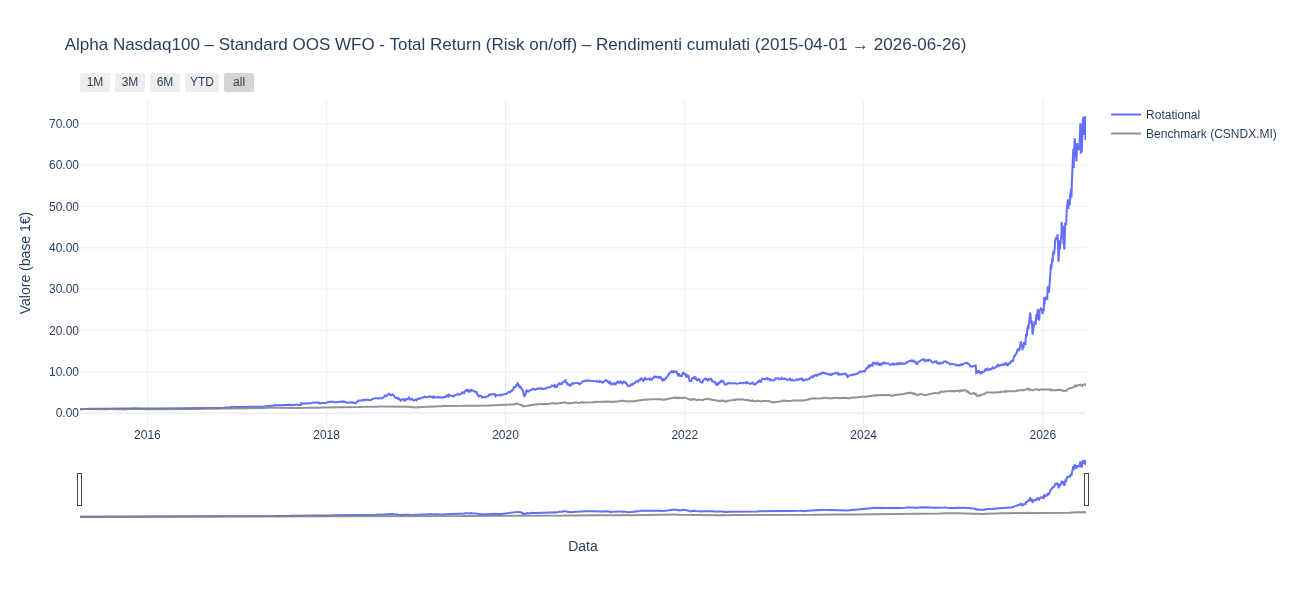


  Alpha Nasdaq100 – Standard OOS WFO - Total Return (Risk on/off)

  Selezioni totali : 46
  Carry-forward    : 0 (0.0%)
  Selezioni vuote  : 0

  --- Stats Rotational ---


Start                                2015-04-01 00:00:00
End                                  2026-06-26 00:00:00
Period                                2902 days 00:00:00
Start Value                                     100000.0
End Value                                 6807793.670431
Total Return [%]                              6707.79367
Benchmark Return [%]                          1451.64066
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               45.856809
Max Drawdown Duration                  549 days 00:00:00
Total Trades                                        5029
Total Closed Trades                                 5026
Total Open Trades                                      3
Open Trade PnL                            1553759.733426
Win Rate [%]                                   67.508953
Best Trade [%]                                 290.70066
Worst Trade [%]                


  --- Stats Benchmark (CSNDX.MI) ---


Start                         2015-04-01 00:00:00
End                           2026-06-26 00:00:00
Period                         2902 days 00:00:00
Start Value                              100000.0
End Value                           672424.420269
Total Return [%]                        572.42442
Benchmark Return [%]                    572.42442
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        31.191485
Max Drawdown Duration           517 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                      572424.420269
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN



  --- Ultime selezioni ---


,tickers,carried,n_passed_filters,universe
rebal_date,,,,
2023-09-29,"[REGN, COST, ADP]",False,102,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2023-12-29,"[CRWD, WDAY, FAST]",False,102,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2024-03-28,"[FANG, CPRT, WMT]",False,102,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2024-06-28,"[VRSK, COST, TXN]",False,102,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2024-09-30,"[XEL, KDP, AEP]",False,102,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2024-12-31,"[CSCO, IBTS.MI, AAPL]",False,102,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2025-03-31,"[SNDK, TMUS, GILD]",False,103,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2025-06-30,"[STX, WDC, MCHP]",False,103,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2025-09-30,"[SNDK, APP, WDC]",False,103,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."


🛠️ Analisi Portfolio Rotazionale (Alpha Nasdaq100):



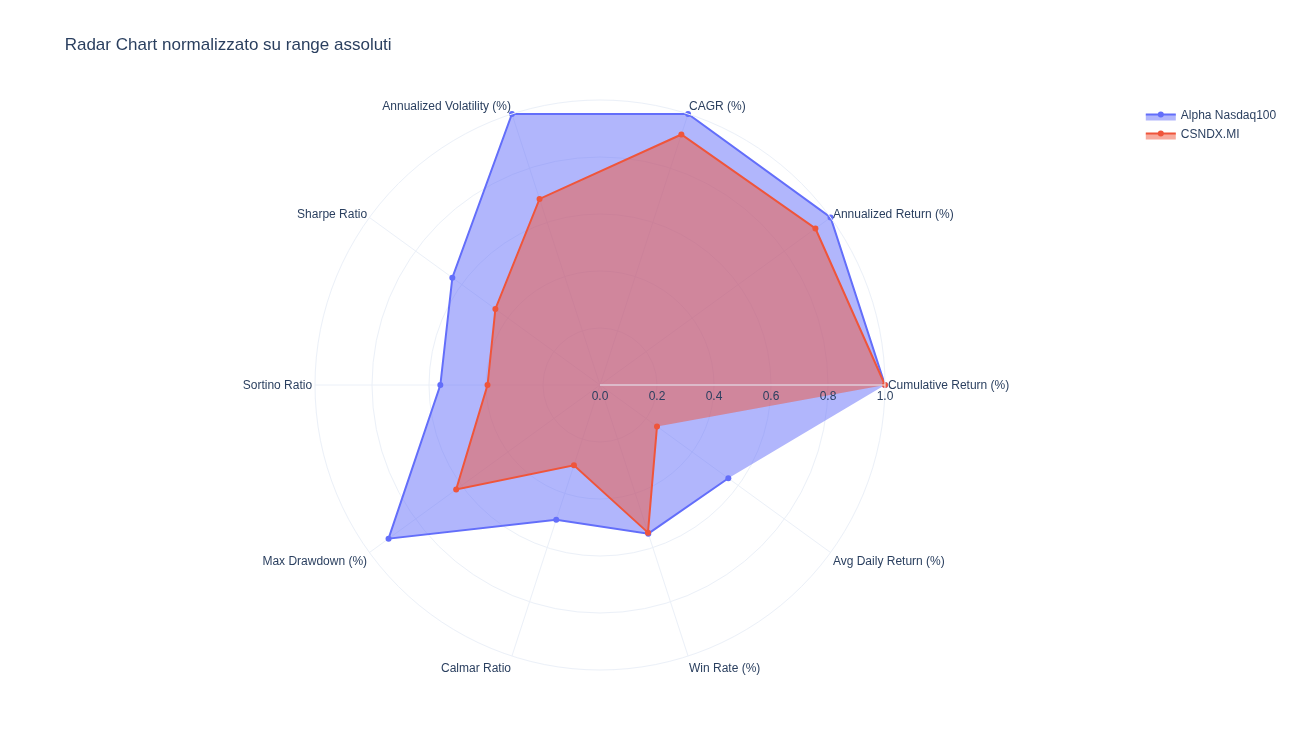


▶ Portafoglio SENZA Risk ON/OFF...


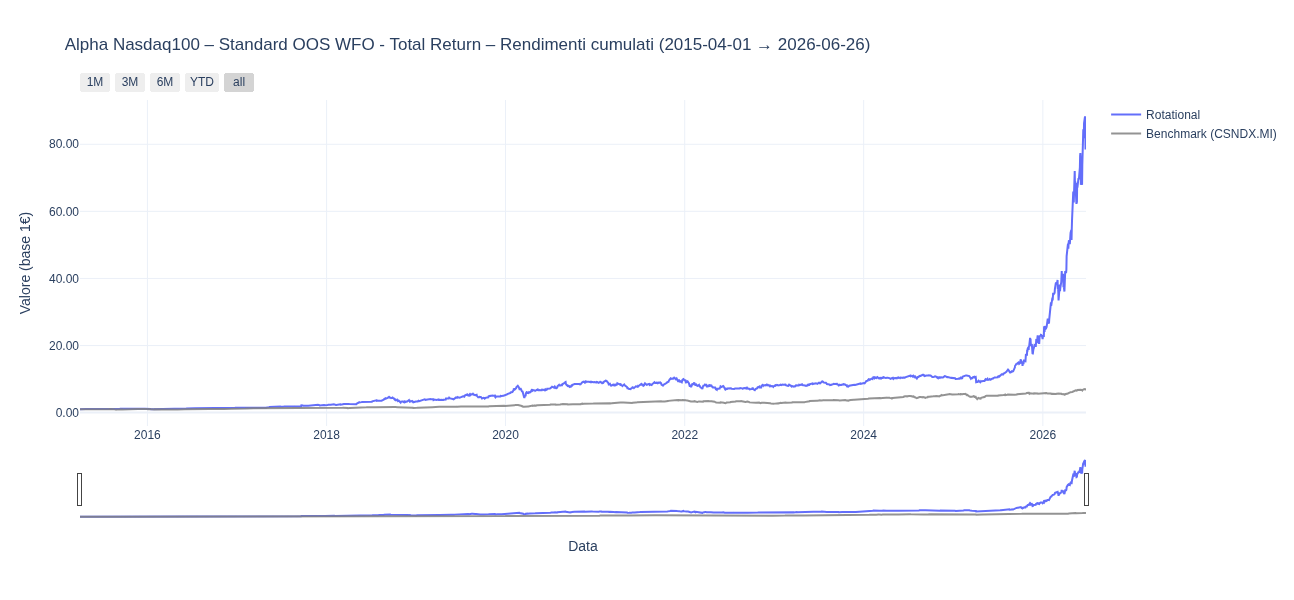


  Alpha Nasdaq100 – Standard OOS WFO - Total Return

  Selezioni totali : 46
  Carry-forward    : 0 (0.0%)
  Selezioni vuote  : 0

  --- Stats Rotational ---


Start                                2015-04-01 00:00:00
End                                  2026-06-26 00:00:00
Period                                2826 days 00:00:00
Start Value                                     100000.0
End Value                                 8023022.606909
Total Return [%]                             7923.022607
Benchmark Return [%]                         1492.900435
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               45.856808
Max Drawdown Duration                  556 days 00:00:00
Total Trades                                        4999
Total Closed Trades                                 4996
Total Open Trades                                      3
Open Trade PnL                            3007485.264137
Win Rate [%]                                   67.033627
Best Trade [%]                                290.894973
Worst Trade [%]                


  --- Stats Benchmark (CSNDX.MI) ---


Start                         2015-04-01 00:00:00
End                           2026-06-26 00:00:00
Period                         2826 days 00:00:00
Start Value                              100000.0
End Value                           672424.420269
Total Return [%]                        572.42442
Benchmark Return [%]                    572.42442
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        31.191485
Max Drawdown Duration           502 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                      572424.420269
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN



  --- Ultime selezioni ---


,tickers,carried,n_passed_filters,universe
rebal_date,,,,
2023-09-29,"[REGN, CTSH, ADP]",False,99,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2023-12-29,"[CRWD, WDAY, FAST]",False,99,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2024-03-28,"[FANG, CPRT, WMT]",False,99,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2024-06-28,"[COST, VRSK, TXN]",False,99,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2024-09-30,"[XEL, AEP, KDP]",False,99,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2024-12-31,"[CSCO, TTWO, AAPL]",False,99,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2025-03-31,"[SNDK, EXC, GILD]",False,100,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2025-06-30,"[STX, AVGO, PLTR]",False,100,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."
2025-09-30,"[SNDK, APP, WDC]",False,100,"[AAPL, ABNB, ADBE, ADI, ADP, ADSK, AEP, ALNY, ..."


🛠️ Analisi Portfolio Rotazionale (Alpha Nasdaq100 (Base)):



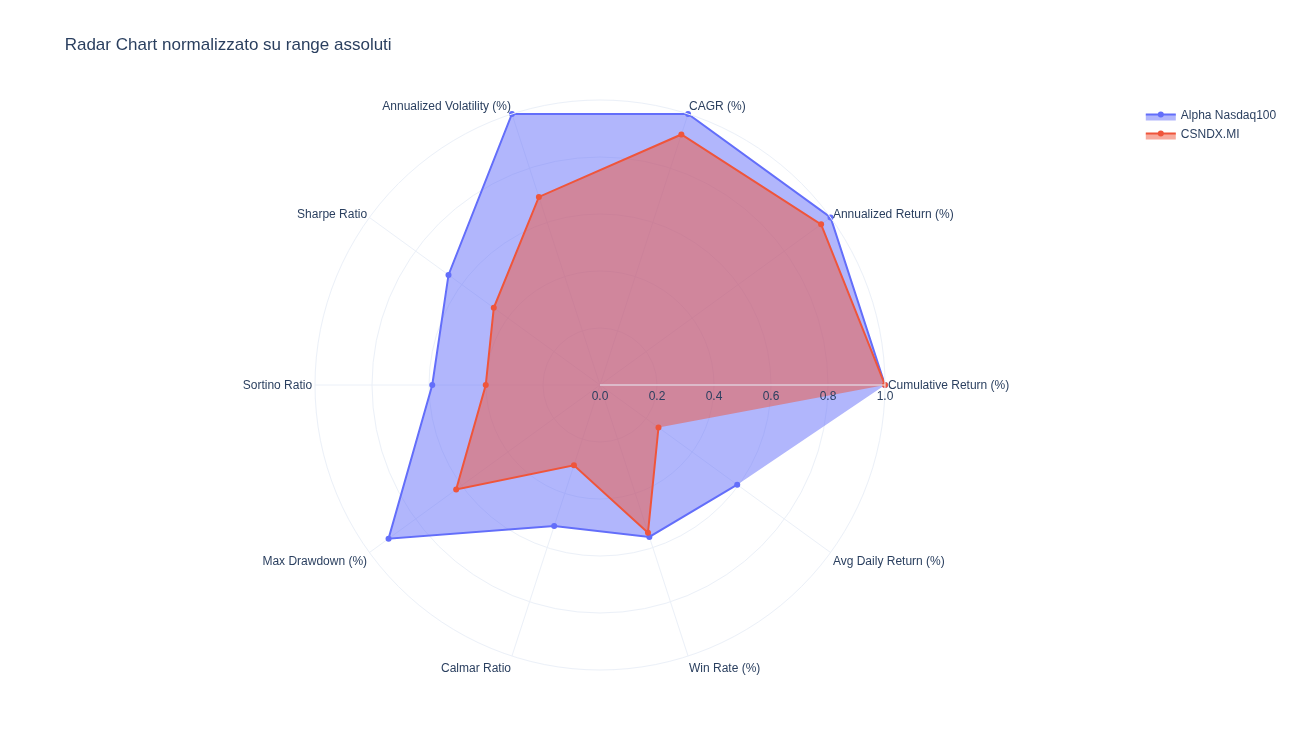


▶ Confronto selezioni Risk ON/OFF vs Base...

PIPELINE COMPLETATA


In [20]:
ratio_int = int(str(ratio).split(':')[0])
benchmark_start    = benchmark_data.dropna(how='all').index.min()
first_full_year    = pd.Timestamp(f"{benchmark_start.year + 1}-01-01")
pipeline_start_date = first_full_year - pd.DateOffset(years=ratio_int)

print(f"Benchmark start:         {benchmark_start.date()}")
print(f"Primo anno pieno comune: {first_full_year.date()}")
print(f"Pipeline start:          {pipeline_start_date.date()}")
print(f"Primo OOS atteso:        {first_full_year.date()}")


results_std = run_wfo_pipeline(
    # Dati
    stocks_data_raw        = stocks_data_raw,
    stocks_data            = stocks_data,
    benchmark_data         = benchmark_data,
    benchmark_data_raw     = benchmark_data_raw,
    tickers                = tickers,
    risk_off_data          = risk_off_data,
    # Parametri WFO
    ratio                  = ratio,
    metric                 = metric,
    start_date             = pipeline_start_date,
    end_date               = end_date,
    cores                  = cores,
    verbose                = verbose,
    force_next_year_params = force_next_year_params,
    use_clustering         = False,
    param_grid             = reduced_grid,   # stability-reduced
    # Parametri portafoglio
    portfolio_title        = portfolio_title,
    benchmark_title        = benchmark_title,
    init_cash              = init_cash,
    risk_on_off            = True,
    plot                   = True,
    profile                = profile,
    asset_type             = portfolio.get('asset_type', 'stock'),
    wfo_audit_path_base    = str(reports_dir / f"{portfolio_title}_{year}"),
)


In [21]:
# Accesso ai risultati
pf_rot_std           = results_std['pf_rot']           # con Risk ON/OFF
pf_rot_std_base      = results_std['pf_rot_base']      # senza Risk ON/OFF
regime               = results_std['regime']
summary_df_std       = results_std['summary_df']
sel_tickers_std      = results_std['sel_tickers']      # con Risk ON/OFF
sel_tickers_std_base = results_std['sel_tickers_base'] # senza Risk ON/OFF

# Verifica colonna universe (pre-condizione MC skill tests)
assert 'universe' in sel_tickers_std_base.columns, "Colonna 'universe' mancante in sel_tickers_std_base"
assert sel_tickers_std_base['universe'].apply(len).min() > 0
print(f"sel_tickers_std_base: {len(sel_tickers_std_base)} righe, universe OK")

sel_tickers_std_base: 46 righe, universe OK


In [22]:
# summary_df_std

### §5b — WFO Clusterizzata

**Nota**: usa `build_cluster_grids` internamente — la `reduced_grid` della stability
non viene applicata. I flag binari variano liberamente per cluster
(debito metodologico, vedere CLAUDE.md).


STEP 1 — Analisi e clustering universo


Filtrati 1 asset con >30% NaN: {'SNDK'}
corr_threshold: rescaling non convergito dopo 5 iter, fallback su silhouette


  K adattivo proposto: 2 (metodo=hybrid→silhouette, score=0.103)
  K massimo ammesso: 5 (universe_size=99, min_cluster_size=4)
  K finale usato: 2

Soglie adattive universo:
  Vol p33=28.5%  p66=44.8%
  Mom6m mediana=4.6%
  Sharpe mediana=0.64

Cluster 2 [AVOID] — 61 asset
  Tickers  : ['ADBE', 'AMD', 'ABNB', 'ALNY', 'GOOGL', 'AMZN', 'ADI', 'AMAT', 'APP', 'ARM', 'ASML', 'ADP', 'AXON', 'AVGO', 'CDNS', 'CHTR', 'CTSH', 'CMCSA', 'CEG', 'CPRT', 'CRWD', 'DDOG', 'DXCM', 'DASH', 'FTNT', 'INSM', 'INTC', 'INTU', 'KLAC', 'LRCX', 'LITE', 'MRVL', 'MELI', 'META', 'MCHP', 'MU', 'MSFT', 'MSTR', 'MPWR', 'NFLX', 'NVDA', 'NXPI', 'PLTR', 'PANW', 'PAYX', 'PYPL', 'PDD', 'QCOM', 'REGN', 'ROP', 'STX', 'SHOP', 'SNPS', 'TSLA', 'TXN', 'TRI', 'VRSK', 'WBD', 'WDC', 'WDAY', 'ZS']
  Avg Vol  : 47.4%
  Avg Mom6m: 28.9%
  Avg MaxDD: -48.5%
  Sharpe   : 0.89

Cluster 1 [DEFENSIVE] — 38 asset
  Tickers  : ['AEP', 'AMGN', 'AAPL', 'ADSK', 'BKR', 'BKNG', 'CTAS', 'CSCO', 'CCEP', 'COST', 'CSX', 'FANG', 'EA', 'EXC', 'FAST', '

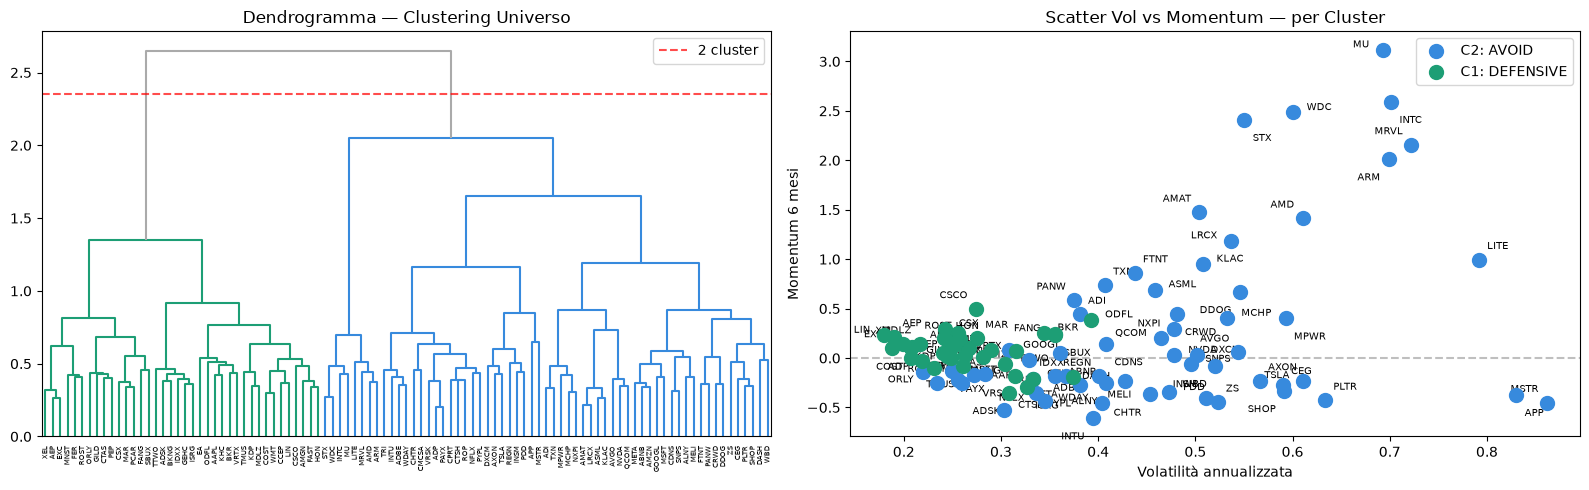

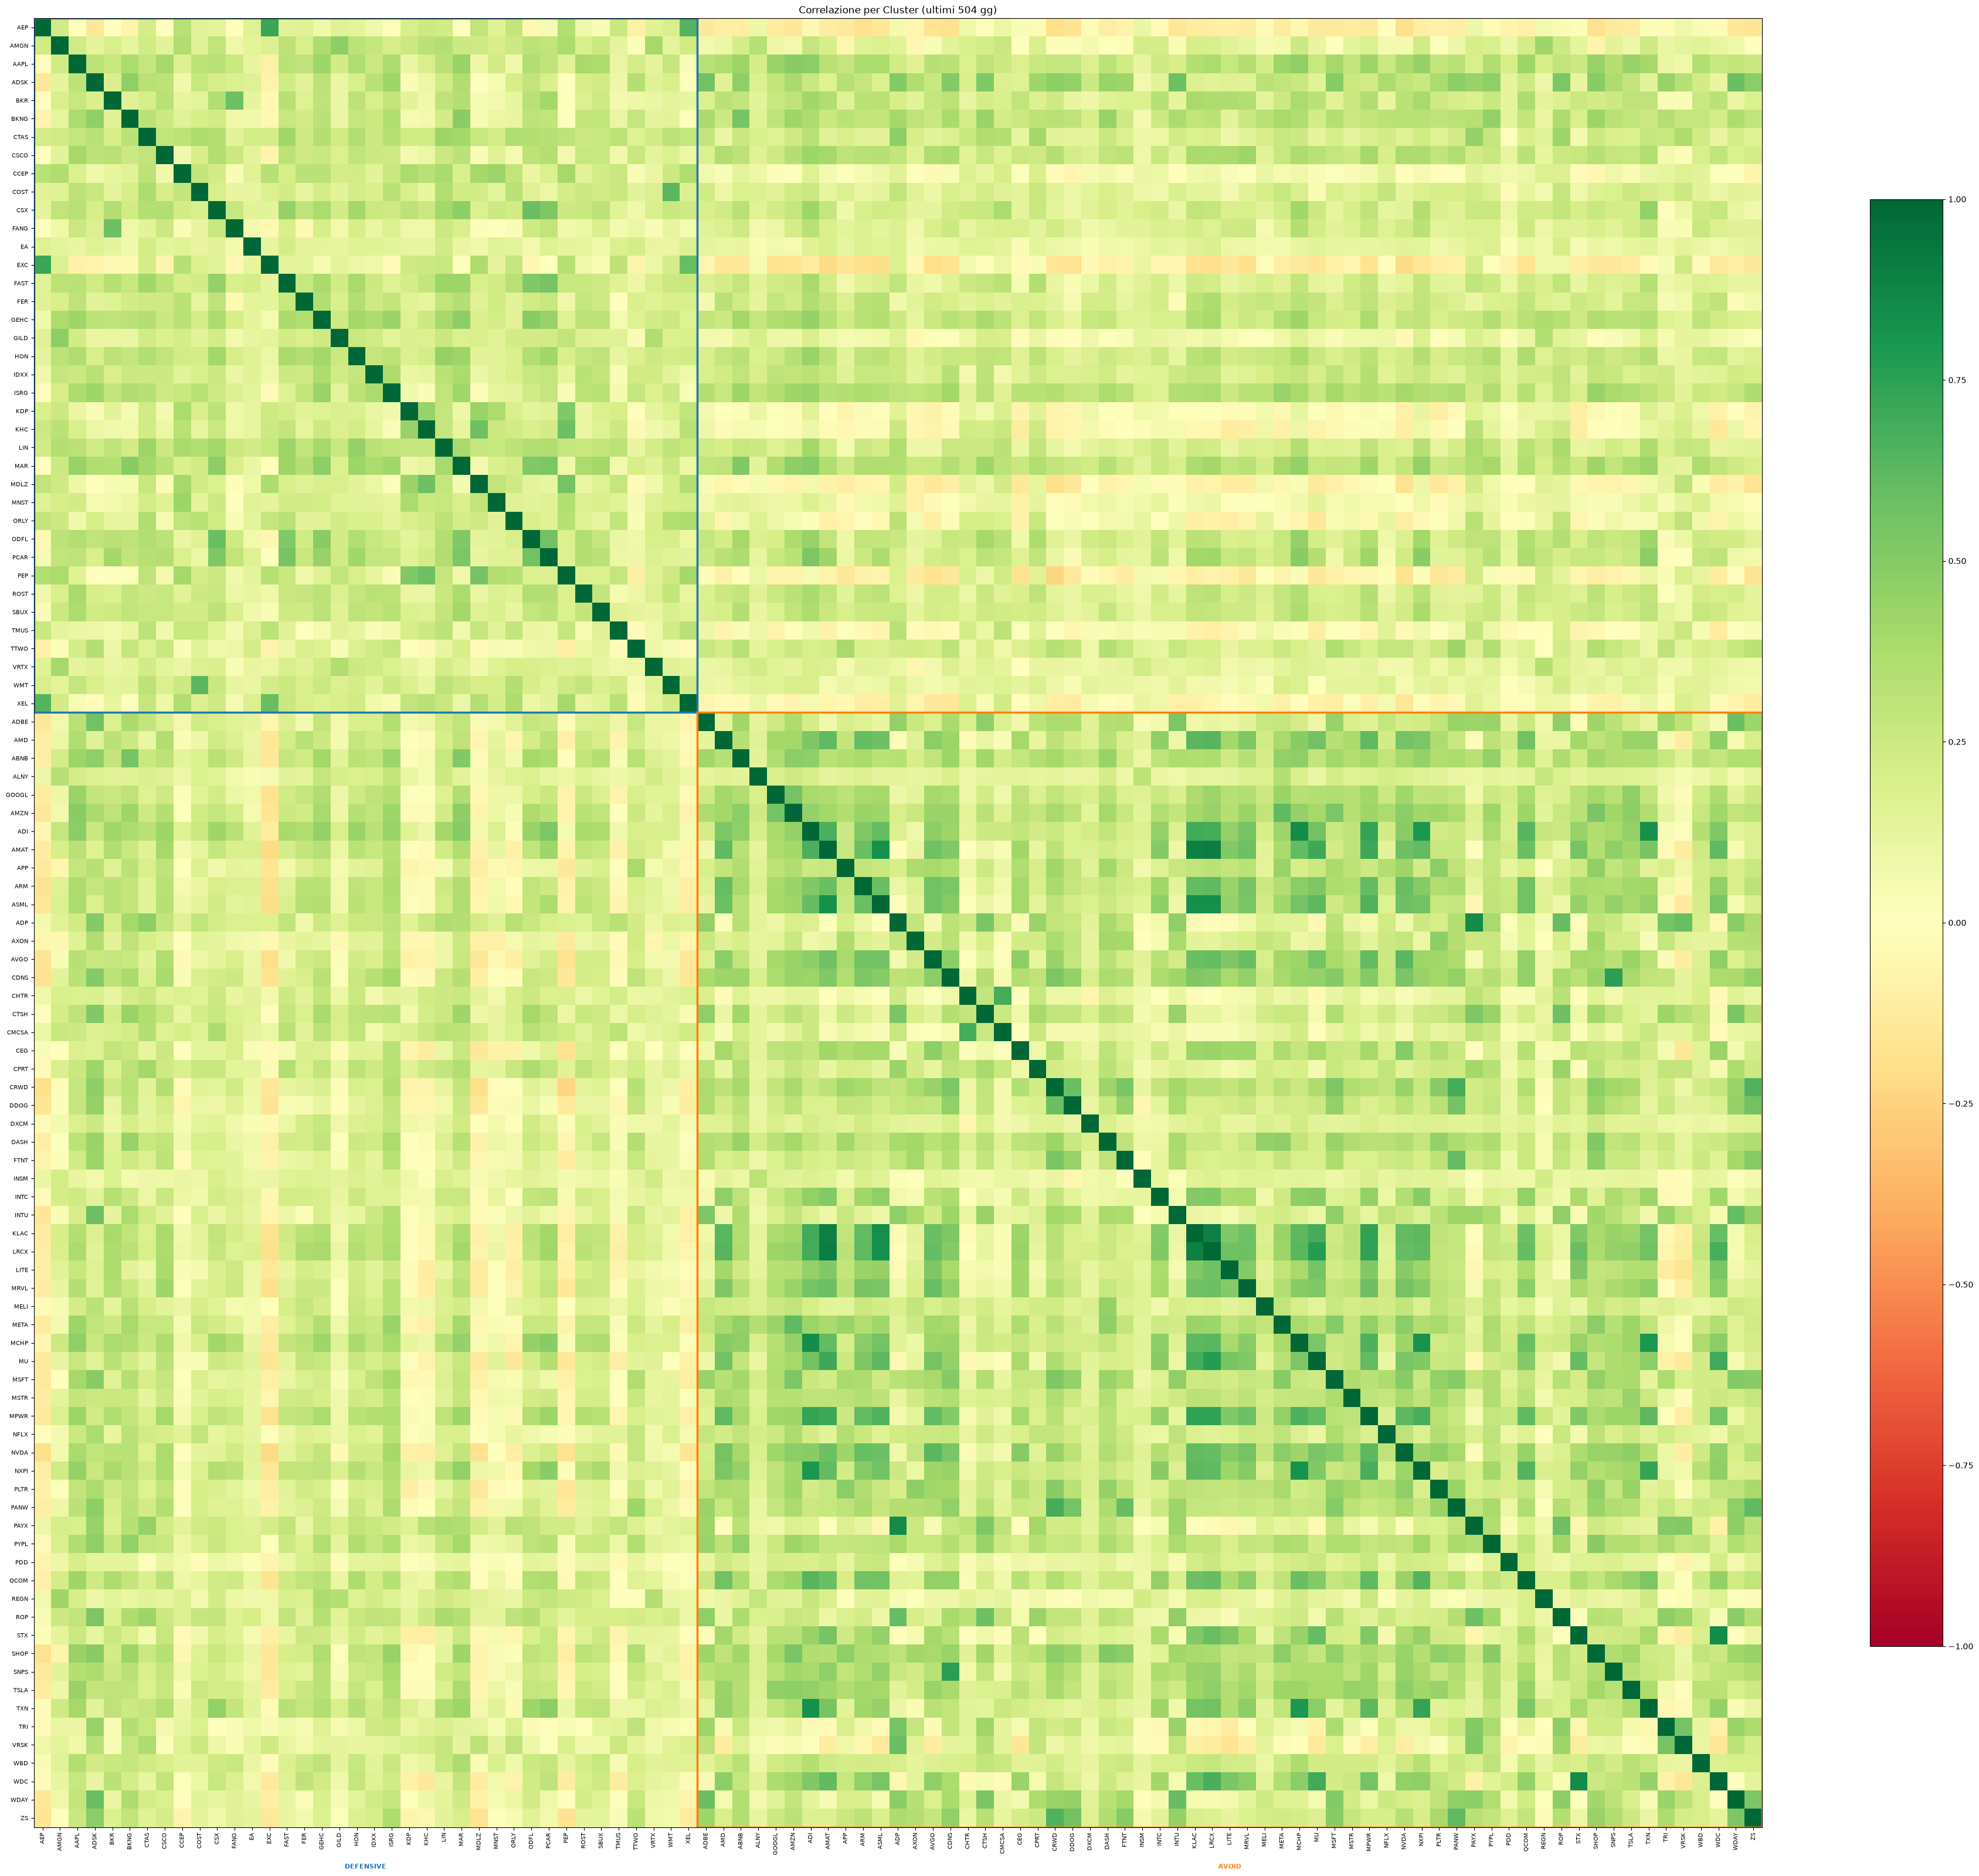

Filtrati 4 asset con >30% NaN: {'KHC', 'LITE', 'SHOP', 'PYPL'}
corr_threshold: rescaling non convergito dopo 5 iter, fallback su silhouette



STEP 1b — Cluster checkpoint espandenti (k=3)
[CLUSTER CP 1/3] Partizione su dati fino al 2018-02-28 (1047 trading days)…
  K adattivo proposto: 2 (metodo=hybrid→silhouette, score=0.151)
  K massimo ammesso: 5 (universe_size=84, min_cluster_size=4)
  K finale usato: 2

Soglie adattive universo:
  Vol p33=22.3%  p66=29.4%
  Mom6m mediana=16.8%
  Sharpe mediana=0.94

Cluster 2 [BALANCED] — 59 asset
  Tickers  : ['ADBE', 'GOOGL', 'AMZN', 'AEP', 'AMGN', 'ADI', 'AAPL', 'ASML', 'ADSK', 'ADP', 'BKNG', 'AVGO', 'CDNS', 'CHTR', 'CTAS', 'CSCO', 'CCEP', 'CTSH', 'CMCSA', 'CPRT', 'COST', 'CSX', 'EA', 'EXC', 'FAST', 'FER', 'HON', 'IDXX', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LRCX', 'LIN', 'MAR', 'META', 'MCHP', 'MSFT', 'MDLZ', 'MPWR', 'MNST', 'NXPI', 'ORLY', 'ODFL', 'PCAR', 'PAYX', 'PEP', 'ROP', 'ROST', 'SBUX', 'SNPS', 'TMUS', 'TTWO', 'TXN', 'TRI', 'VRSK', 'WMT', 'XEL']
  Avg Vol  : 22.9%
  Avg Mom6m: 16.2%
  Avg MaxDD: -25.3%
  Sharpe   : 1.06

Cluster 1 [AVOID] — 25 asset
  Tickers  : ['AMD', 'A

Filtrati 9 asset con >30% NaN: {'ABNB', 'PDD', 'DDOG', 'CRWD', 'PLTR', 'APP', 'CEG', 'DASH', 'ZS'}
corr_threshold: rescaling non convergito dopo 5 iter, fallback su silhouette
Filtrati 12 asset con >30% NaN: {'SNDK', 'ABNB', 'PDD', 'DDOG', 'CRWD', 'PLTR', 'APP', 'GEHC', 'CEG', 'DASH', 'ZS', 'ARM'}
corr_threshold: rescaling non convergito dopo 5 iter, fallback su silhouette


  K adattivo proposto: 2 (metodo=hybrid→silhouette, score=0.153)
  K massimo ammesso: 5 (universe_size=84, min_cluster_size=4)
  K finale usato: 2

Soglie adattive universo:
  Vol p33=27.3%  p66=35.0%
  Mom6m mediana=-7.1%
  Sharpe mediana=0.80

Cluster 2 [BALANCED] — 66 asset
  Tickers  : ['ADBE', 'GOOGL', 'AMZN', 'AEP', 'AMGN', 'ADI', 'AAPL', 'AMAT', 'ASML', 'ADSK', 'ADP', 'BKNG', 'AVGO', 'CDNS', 'CHTR', 'CTAS', 'CSCO', 'CCEP', 'CTSH', 'CMCSA', 'CPRT', 'COST', 'CSX', 'EA', 'EXC', 'FAST', 'FER', 'FTNT', 'GILD', 'HON', 'IDXX', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LRCX', 'LIN', 'MRVL', 'META', 'MCHP', 'MSFT', 'MDLZ', 'MPWR', 'MNST', 'NXPI', 'ORLY', 'ODFL', 'PCAR', 'PANW', 'PAYX', 'PEP', 'QCOM', 'REGN', 'ROP', 'ROST', 'SBUX', 'SNPS', 'TMUS', 'TTWO', 'TXN', 'TRI', 'VRSK', 'VRTX', 'WMT', 'XEL']
  Avg Vol  : 29.1%
  Avg Mom6m: -5.2%
  Avg MaxDD: -39.9%
  Sharpe   : 0.85

Cluster 1 [AVOID] — 18 asset
  Tickers  : ['AMD', 'ALNY', 'AXON', 'BKR', 'DXCM', 'FANG', 'INSM', 'MAR', 'MELI', 'MU', 

WFO Parallel:   0%|          | 0/13 [00:00<?, ?it/s]

...

WFO Results Cluster 1 [DEFENSIVE]


,freq,mom_lb,rp_lb,n_top,use_acceleration,mom_w,f_ema,f_vol,f_min_m,TrainScore,TestScore
Window,,,,,,,,,,,
2015-01-01→2015-12-31,ME,60,60,8,False,0.5,True,True,True,3.692070,0.842915
2016-01-01→2016-12-31,ME,60,60,5,False,0.7,True,True,True,2.388371,0.166354
2017-01-01→2017-12-31,ME,60,60,3,False,0.7,True,True,True,1.647585,3.001789
2018-01-01→2018-12-31,ME,60,60,3,False,0.7,True,True,True,1.727811,0.212030
2019-01-01→2019-12-31,ME,120,120,5,False,0.7,True,True,True,1.721604,2.410191
2020-01-01→2020-12-31,ME,180,120,3,False,0.5,True,True,True,1.907432,1.038792
2021-01-01→2021-12-31,ME,120,120,8,False,0.7,True,True,True,1.038200,1.301865
2022-01-01→2022-12-31,ME,180,120,8,False,0.5,True,True,True,1.229050,0.029407
2023-01-01→2023-12-31,ME,180,120,3,False,0.5,True,True,False,0.727064,0.614417



STEP 4 — Regime Risk ON/OFF
Regime ON : 68.0% del tempo
Regime OFF: 32.0% del tempo

STEP 5 — Merge summary_df aggregato
  Window 2015-01-01→2015-12-31: ON  → AVOID [satellite ON: TestScore AVOID=0.7680 (unico disponibile)]
  Window 2016-01-01→2016-12-31: ON  → AVOID [satellite ON: TestScore AVOID=2.1682 (unico disponibile)]
  Window 2017-01-01→2017-12-31: ON  → AVOID [satellite ON: TestScore AVOID=1.1509 (unico disponibile)]
  Window 2018-01-01→2018-12-31: OFF → DEFENSIVE [satellite OFF: deterministico]
  Window 2019-01-01→2019-12-31: ON  → AVOID [satellite ON: TestScore AVOID=1.9589 (unico disponibile)]
  Window 2020-01-01→2020-12-31: ON  → AVOID [satellite ON: TestScore AVOID=2.1482 (unico disponibile)]
  Window 2021-01-01→2021-12-31: OFF → DEFENSIVE [satellite OFF: deterministico]
  Window 2022-01-01→2022-12-31: OFF → DEFENSIVE [satellite OFF: deterministico]
  Window 2023-01-01→2023-12-31: ON  → AVOID [satellite ON: TestScore AVOID=2.6467 (unico disponibile)]
  Window 2024-01-01→

,freq,mom_lb,rp_lb,n_top,use_acceleration,mom_w,f_ema,f_vol,f_min_m,TrainScore,TestScore
Window,,,,,,,,,,,
2015-01-01→2015-12-31,ME,60,120,8,False,1.0,True,True,True,2.549208,0.768030
2016-01-01→2016-12-31,ME,60,120,3,False,1.0,True,True,True,2.493929,2.168232
2017-01-01→2017-12-31,ME,60,120,3,False,1.0,True,True,True,2.471112,1.150863
2018-01-01→2018-12-31,ME,60,60,3,False,0.7,True,True,True,1.727811,0.212030
2019-01-01→2019-12-31,ME,120,120,3,False,1.0,True,True,True,2.487342,1.958943
2020-01-01→2020-12-31,ME,120,60,5,False,1.0,True,True,True,2.085610,2.148161
2021-01-01→2021-12-31,ME,120,120,8,False,0.7,True,True,True,1.038200,1.301865
2022-01-01→2022-12-31,ME,180,120,8,False,0.5,True,True,True,1.229050,0.029407
2023-01-01→2023-12-31,ME,60,60,3,False,1.0,True,True,True,1.982718,2.646685


[WFO SAVE OK] File salvato correttamente: '../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/Alpha Nasdaq100_2026.cluster_raw.csv' | Righe: 13 | Metric: Sharpe Ratio | Ratio: 3:1 | Data start: 2012-01-01 00:00:00 | Data end: None | Force next year params: True
[run_wfo_pipeline] Audit trail salvato (Cluster): ../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/Alpha Nasdaq100_2026.cluster_raw.csv

STEP 6 — Costruzione portafogli

[STEP 6] Pool eleggibili per finestra (profile=satellite):
  [EXPANDING] Partizione per-finestra da checkpoint espandenti (3 checkpoint).
[WARN] Finestra 2015-01-01 precede tutti i checkpoint (primo: 2018-02-28) — uso primo checkpoint (possibile look-ahead minimo).
  [INFO] window=2015-01-01→2015-12-31 ON : label ['HIGH_MOMENTUM'] assenti dalla partizione — pool usa solo ['AVOID'].
  2015-01-01→2015-12-31: ON  pool_labels=['AVOID', 'HIGH_MOMENTUM'] presenti=['AVOID'] n_ticker=25 (+3 risk-off)
[WARN] Finestra 2016-01-01 precede tutti i checkpoint (p

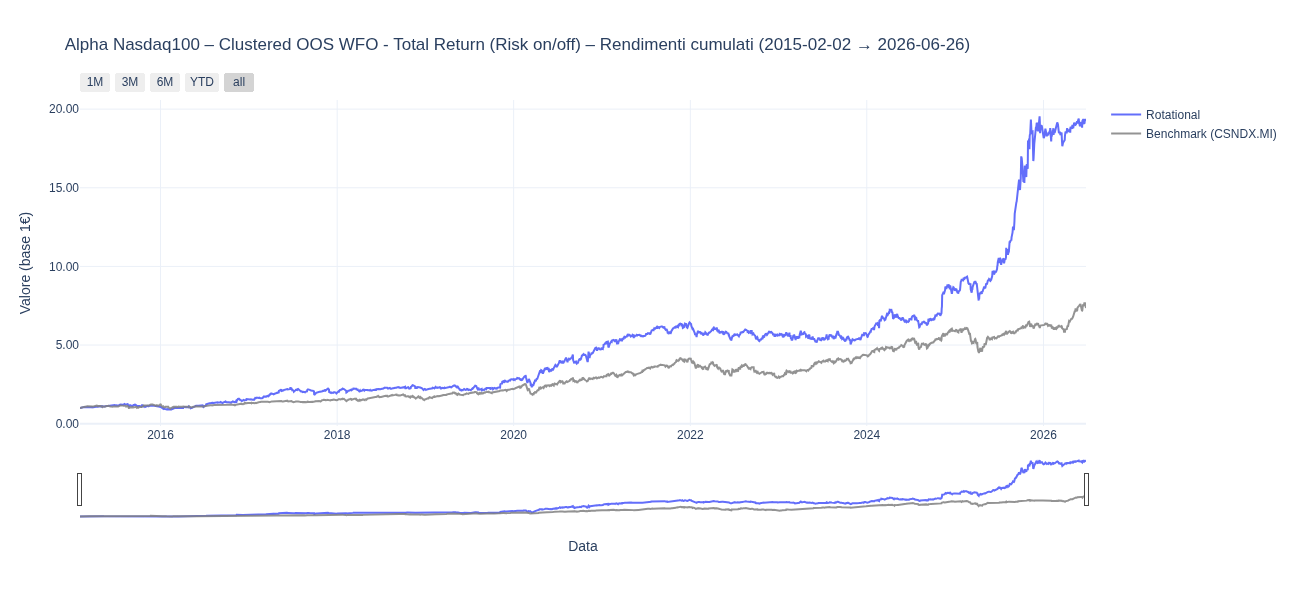


  Alpha Nasdaq100 – Clustered OOS WFO - Total Return (Risk on/off)

  Selezioni totali : 137
  Carry-forward    : 0 (0.0%)
  Selezioni vuote  : 0

  --- Stats Rotational ---


Start                                2015-02-02 00:00:00
End                                  2026-06-26 00:00:00
Period                                2944 days 00:00:00
Start Value                                     100000.0
End Value                                 1936311.232264
Total Return [%]                             1836.311232
Benchmark Return [%]                         1488.852325
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               28.973902
Max Drawdown Duration                  555 days 00:00:00
Total Trades                                        6048
Total Closed Trades                                 6040
Total Open Trades                                      8
Open Trade PnL                             117440.260396
Win Rate [%]                                   73.096026
Best Trade [%]                                141.746969
Worst Trade [%]                


  --- Stats Benchmark (CSNDX.MI) ---


Start                         2015-02-02 00:00:00
End                           2026-06-26 00:00:00
Period                         2944 days 00:00:00
Start Value                              100000.0
End Value                           735322.514084
Total Return [%]                       635.322514
Benchmark Return [%]                   635.322514
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        31.191485
Max Drawdown Duration           517 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                      635322.514084
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN



  --- Ultime selezioni ---


,tickers,carried,n_passed_filters,universe
rebal_date,,,,
2025-06-30,"[STX, WDC, AXON]",False,11,"[ALNY, AXON, DXCM, INSM, MAR, MELI, NFLX, STX,..."
2025-07-31,"[WDC, STX, INSM]",False,9,"[ALNY, BKR, INSM, MAR, NFLX, NVDA, STX, WDC, X..."
2025-08-29,"[ALNY, WDC, STX]",False,8,"[ALNY, BKR, MAR, NVDA, STX, WDC, XAD5.MI, XEON..."
2025-09-30,"[WDC, STX, ALNY]",False,9,"[ALNY, AMD, BKR, MU, NVDA, STX, WDC, XAD5.MI, ..."
2025-10-31,"[WDC, MU, XAD5.MI]",False,8,"[ALNY, BKR, MU, NVDA, WDC, IBTS.MI, XAD5.MI, X..."
2025-11-28,"[INSM, TSLA, XAD5.MI]",False,9,"[BKR, FANG, INSM, MAR, NVDA, TSLA, IBTS.MI, XA..."
2025-12-31,"[MAR, XAD5.MI, INSM]",False,7,"[FANG, INSM, MAR, NVDA, TSLA, XAD5.MI, XEON.MI]"
2026-01-30,"[XAD5.MI, AAPL, FER, AEP, MNST, PEP, XEL, CSCO]",False,29,"[AAPL, ADI, AEP, AMGN, AMZN, CCEP, CSCO, CSX, ..."
2026-02-27,"[ROST, AEP, FER, CSX, XEL, MNST, PEP, EXC]",False,28,"[AAPL, ADI, AEP, AMGN, CCEP, COST, CSCO, CSX, ..."


🛠️ Analisi Portfolio Rotazionale (Alpha Nasdaq100):



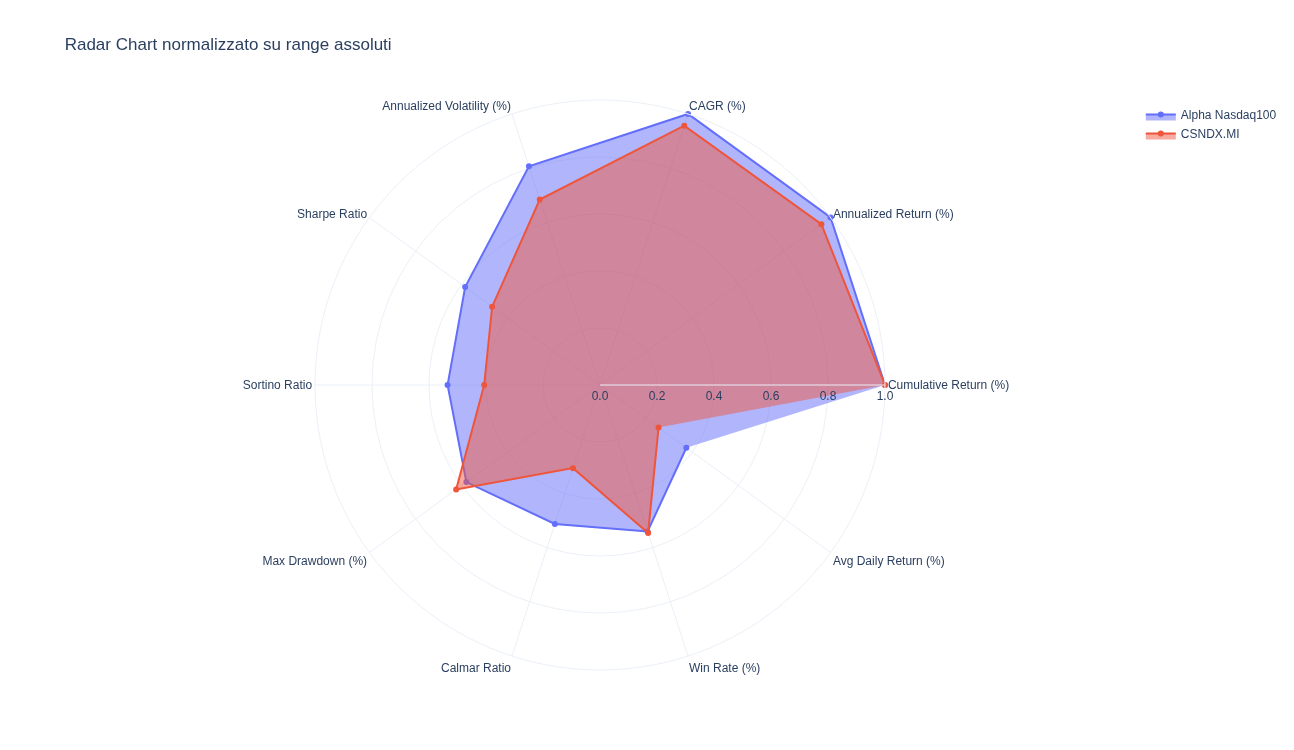


▶ Portafoglio SENZA Risk ON/OFF...


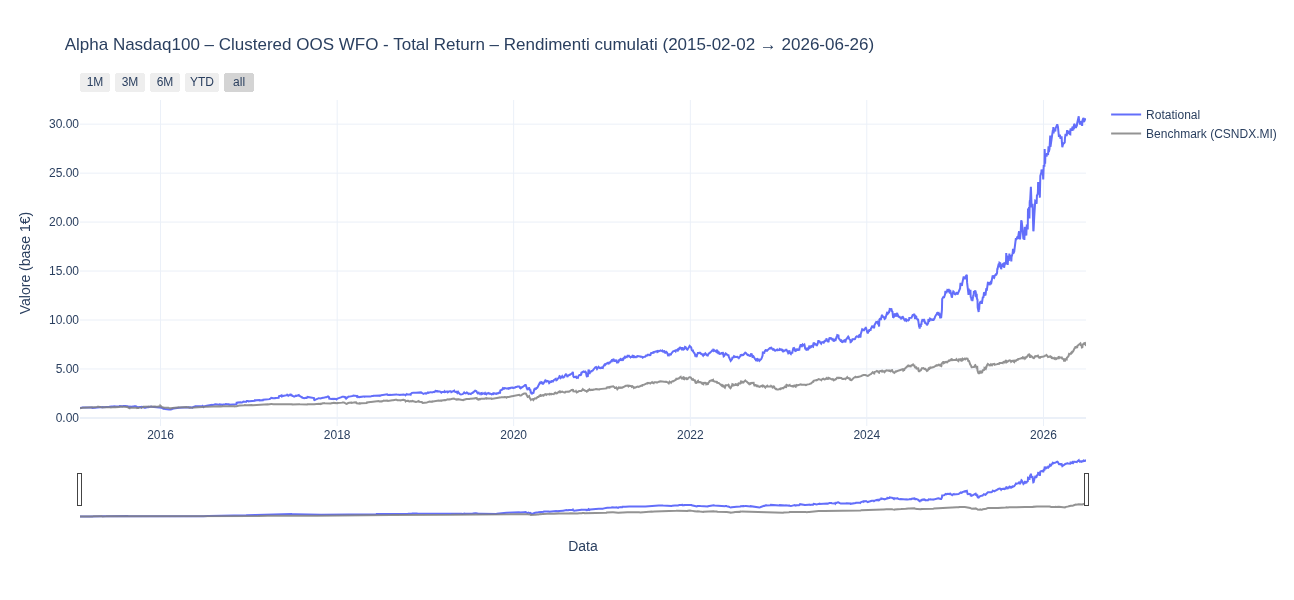


  Alpha Nasdaq100 – Clustered OOS WFO - Total Return

  Selezioni totali : 137
  Carry-forward    : 1 (0.7%)
  Selezioni vuote  : 0
  Date carry-fwd   : [datetime.date(2016, 2, 29)]

  --- Stats Rotational ---


Start                                2015-02-02 00:00:00
End                                  2026-06-26 00:00:00
Period                                2867 days 00:00:00
Start Value                                     100000.0
End Value                                 3050396.441253
Total Return [%]                             2950.396441
Benchmark Return [%]                         1531.192988
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               32.833295
Max Drawdown Duration                  314 days 00:00:00
Total Trades                                        5801
Total Closed Trades                                 5793
Total Open Trades                                      8
Open Trade PnL                             165985.322729
Win Rate [%]                                   74.382876
Best Trade [%]                                164.811584
Worst Trade [%]                


  --- Stats Benchmark (CSNDX.MI) ---


Start                         2015-02-02 00:00:00
End                           2026-06-26 00:00:00
Period                         2867 days 00:00:00
Start Value                              100000.0
End Value                           735322.514084
Total Return [%]                       635.322514
Benchmark Return [%]                   635.322514
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        31.191485
Max Drawdown Duration           502 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                      635322.514084
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN



  --- Ultime selezioni ---


,tickers,carried,n_passed_filters,universe
rebal_date,,,,
2025-06-30,"[STX, WDC, AXON]",False,10,"[ALNY, AXON, DXCM, INSM, MAR, MELI, NFLX, STX,..."
2025-07-31,"[AMD, WDC, STX]",False,10,"[ALNY, AMD, BKR, INSM, MAR, MELI, NFLX, NVDA, ..."
2025-08-29,"[INSM, WDC, ALNY]",False,7,"[ALNY, BKR, INSM, MAR, NVDA, STX, WDC]"
2025-09-30,"[WDC, STX, ALNY]",False,6,"[ALNY, BKR, MU, NVDA, STX, WDC]"
2025-10-31,"[WDC, MU, STX]",False,6,"[ALNY, BKR, MU, NVDA, STX, WDC]"
2025-11-28,"[MU, WDC, TSLA]",False,7,"[BKR, FANG, MAR, MU, NVDA, TSLA, WDC]"
2025-12-31,"[WDC, MAR, INSM]",False,5,"[FANG, INSM, MAR, NVDA, WDC]"
2026-01-30,"[FER, AEP, MNST, XEL, CSCO, PEP, AAPL, GILD]",False,27,"[AAPL, ADI, AEP, AMGN, AMZN, CCEP, CSCO, CSX, ..."
2026-02-27,"[ROST, AEP, FER, CSX, MNST, XEL, EA, PEP]",False,27,"[AAPL, ADI, AEP, AMGN, CCEP, COST, CSCO, CSX, ..."


🛠️ Analisi Portfolio Rotazionale (Alpha Nasdaq100 (Base)):



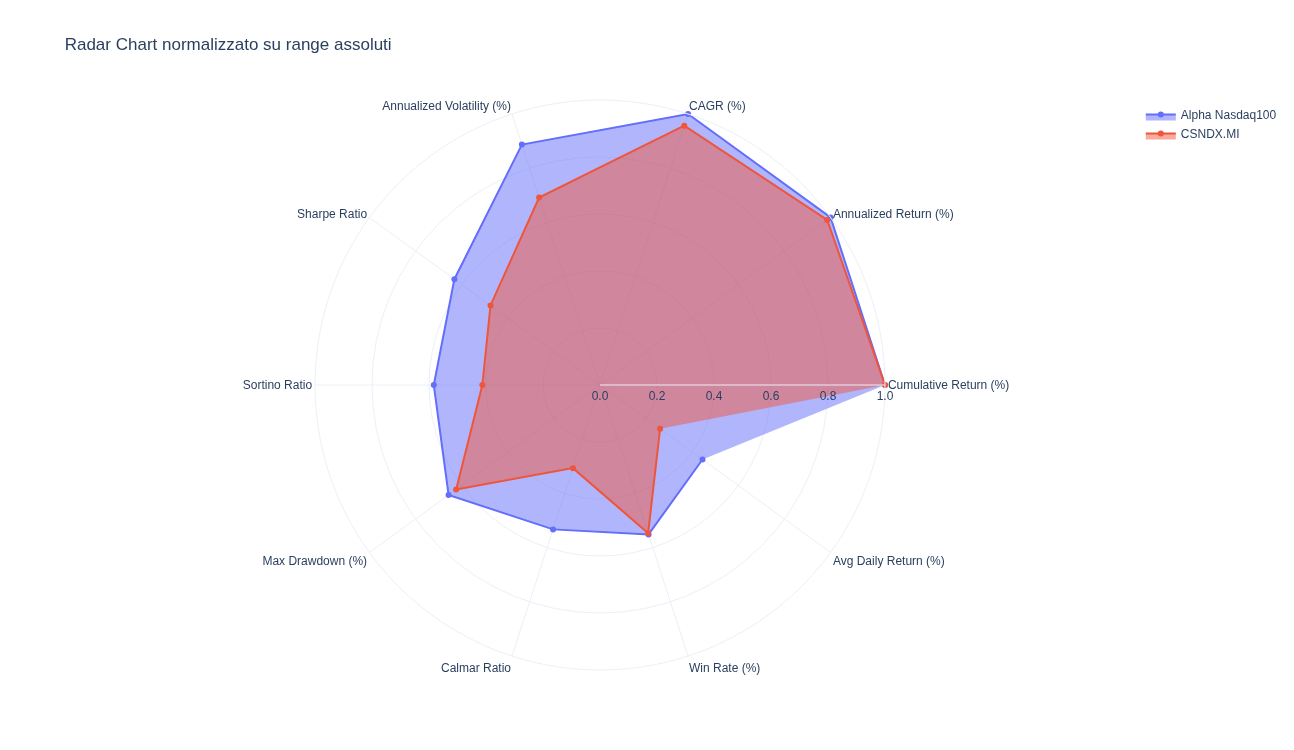


▶ Confronto selezioni Risk ON/OFF vs Base...

PIPELINE COMPLETATA


In [23]:
use_clustering     = True
adaptive_k         = True
adaptive_k_method  = 'hybrid'
max_clusters       = 5
lookback_days      = 504
n_top_min          = 2
save_plots         = True

results_cluster = run_wfo_pipeline(
    # Dati
    stocks_data_raw    = stocks_data_raw,
    stocks_data        = stocks_data,
    benchmark_data     = benchmark_data,
    benchmark_data_raw = benchmark_data_raw,
    tickers            = tickers,
    risk_off_data      = risk_off_data,
    # Parametri WFO
    ratio              = ratio,
    metric             = metric,
    start_date         = pipeline_start_date,
    end_date           = end_date,
    cores              = cores,
    verbose            = verbose,
    force_next_year_params = force_next_year_params,
    # Parametri clustering
    use_clustering     = use_clustering,
    adaptive_k         = adaptive_k,
    adaptive_k_method  = adaptive_k_method,
    n_clusters         = max_clusters,
    lookback_days      = lookback_days,
    n_top_min          = n_top_min,
    # Parametri portafoglio
    portfolio_title    = portfolio_title,
    benchmark_title    = benchmark_title,
    init_cash          = init_cash,
    risk_on_off        = True,
    plot               = True,
    # Salvataggio plot
    save_plots         = save_plots,
    plots_dir          = plots_dir,
    profile            = profile,
    asset_type         = portfolio.get('asset_type', 'stock'),
    wfo_audit_path_base = str(reports_dir / f"{portfolio_title}_{year}"),
)

pf_rot_cluster           = results_cluster['pf_rot']
pf_rot_cluster_base      = results_cluster['pf_rot_base']
regime_cluster           = results_cluster['regime']
summary_df_cluster       = results_cluster['summary_df']
sel_tickers_cluster      = results_cluster['sel_tickers']
sel_tickers_cluster_base = results_cluster['sel_tickers_base']

# results_cluster = None   # placeholder se non eseguita

### §5c — Confronto WFO

Confronto metriche di performance Standard vs Clusterizzata.
Il confronto dei verdetti OFC (S1-S4) è in §6.

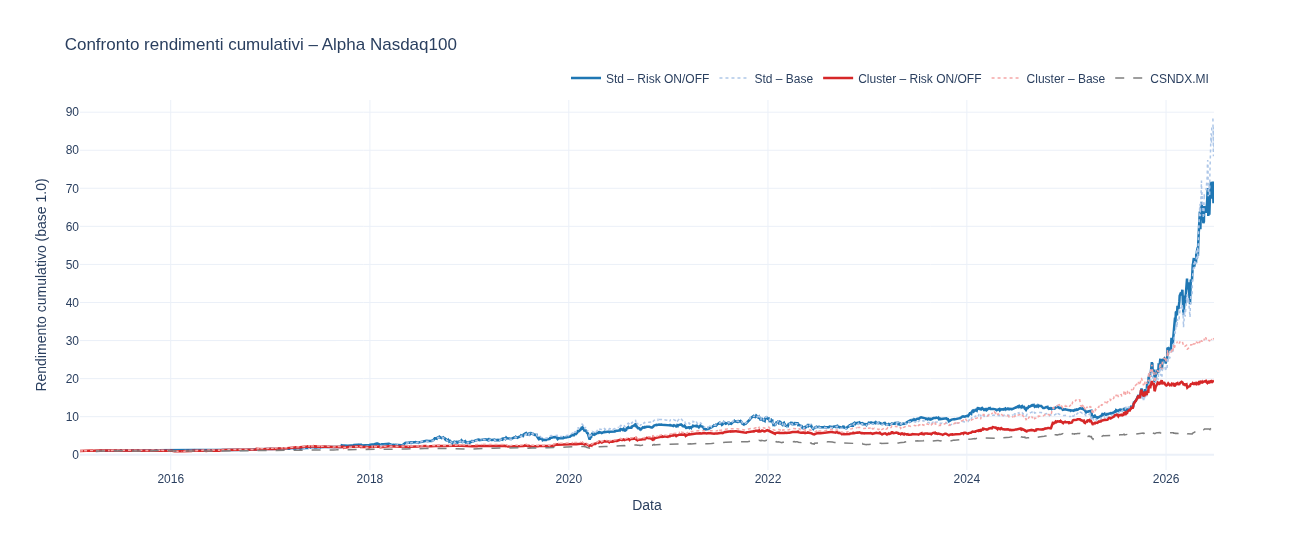

🛠️ Analisi Portfolio Rotazionale (Confronto WFO – Alpha Nasdaq100):



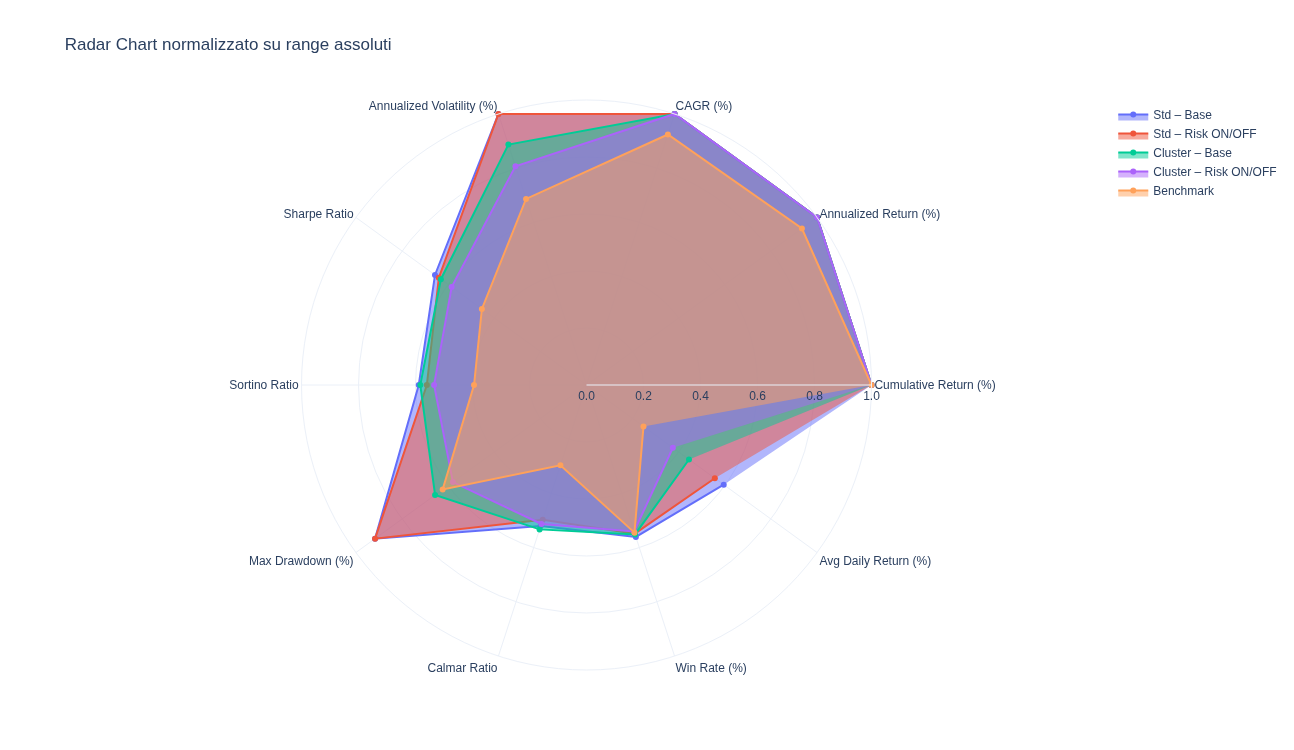

,Cumulative Return (%),Annualized Return (%),CAGR (%),Annualized Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Avg Daily Return (%)
Std – Base,7923.02,44.99,47.73,34.24,1.31,1.77,45.86,1.04,56.04,0.18
Std – Risk ON/OFF,6707.79,42.08,45.59,32.85,1.28,1.68,45.86,0.99,54.84,0.17
Cluster – Base,2950.40,33.61,34.98,26.61,1.26,1.75,32.83,1.07,55.13,0.13
Cluster – Risk ON/OFF,1836.31,28.31,29.70,24.21,1.17,1.60,28.97,1.03,54.03,0.11
Benchmark,572.42,18.69,18.48,20.59,0.91,1.18,31.19,0.59,54.46,0.07


In [24]:
if results_cluster is not None:
    metrics_df = compare_wfo_pipelines(
        results_std     = results_std,
        results_cluster = results_cluster,
        portfolio_title = portfolio_title,
        benchmark_title = benchmark_title,
        plot_radar      = True,
        save_plots      = True,
        plots_dir       = plots_dir,
    )
    display(metrics_df)
else:
    print("WFO Clusterizzata non eseguita — confronto non disponibile.")

## §6 — Overfitting Check

Valuta 4 segnali di overfitting (S1 plateau, S2 coerenza flag,
S3 cross-sectional skill, S4 DSR). Verdetti separati per Standard e Cluster.
Vedi CLAUDE.md "Interpretation framework: Reshuffle vs S3".

In [25]:
import json
import itertools
from pathlib import Path

# --- OFC Standard ---
ofc_passed_std, ofc_report_std = overfitting_check_rotational(
    wfo_summary      = summary_df_std,
    stocks_data      = stocks_data,
    benchmark_data   = benchmark_data,
    param_grid       = reduced_grid,
    profile          = profile,
    n_total_trials   = n_full_trials,     # penalizzazione conservativa: full grid
    stability_report = stability_report,
    seed             = 42,
    verbose          = True,
)

# Salva ofc_report come JSON (audit trail; caricabile in §10 senza re-run)
ofc_report_path = reports_dir / f"{portfolio_title}_{year}_ofc_std.json"
Path(ofc_report_path).parent.mkdir(parents=True, exist_ok=True)
with open(ofc_report_path, "w") as f:
    json.dump(ofc_report_std, f, default=str, indent=2)
print(f"OFC report std salvato: {ofc_report_path}")
print(f"OFC Standard — promoted={ofc_passed_std}")

OFC Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


  Overfitting Check — profile='satellite'  metric(S3)=CAGR
  n_trials(S4)=4608  OOS windows=13
  Signal           Pass?      Value  Note (truncated)
  --------------------------------------------------------------
  S1 plateau        PASS    +0.8750  S1: diversity=0.875 >threshold=0.20? params=['momentum_
  S2 coherence      FAIL    +0.2500  S2: 1/4 coherent=0.25 >=threshold=0.50 (source: stabili
  S3 bootstrap      PASS    +0.0010  S3 (CAGR): actual=0.4592, p=0.001 <=threshold=0.10, n=1
  S4 DSR            PASS    +1.1738  S4 (DSR on Sharpe): SR=1.2393, n=4608, T=2887, DSR=1.17
  ──────────────────────────────────────────────────────────────
  Signals: 3/4 (need 3)
  Verdict: PROMOTED ✓

OFC report std salvato: ../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/Alpha Nasdaq100_2026_ofc_std.json
OFC Standard — promoted=True


In [26]:
# --- OFC Cluster (solo se WFO Clusterizzata è stata eseguita) ---
if 'results_cluster' in locals() and results_cluster is not None:
    ofc_passed_cluster, ofc_report_cluster = overfitting_check_rotational(
        wfo_summary      = summary_df_cluster,
        stocks_data      = stocks_data,
        benchmark_data   = benchmark_data,
        param_grid       = full_grid,       # cluster usa full_grid (no stability)
        profile          = profile,
        n_total_trials   = n_full_trials,
        seed             = 42,
        verbose          = True,
    )
    ofc_report_cluster_path = reports_dir / f"{portfolio_title}_{year}_ofc_cluster.json"
    Path(ofc_report_cluster_path).parent.mkdir(parents=True, exist_ok=True)
    with open(ofc_report_cluster_path, "w") as f:
        json.dump(ofc_report_cluster, f, default=str, indent=2)
    print(f"OFC report cluster salvato: {ofc_report_cluster_path}")
    print(f"OFC Cluster — promoted={ofc_passed_cluster}")

    # Tabella comparativa OFC Standard vs Cluster
    print("\n=== Confronto OFC Standard vs Cluster ===")
    for sig in ['s1_plateau', 's2_coherence', 's3_random_selection', 's4_dsr']:
        v_std = ofc_report_std.get(sig, {}).get('passed', '?')
        v_clu = ofc_report_cluster.get(sig, {}).get('passed', '?')
        print(f"  {sig:25s}  STD={'PASS' if v_std else 'FAIL'}  CLU={'PASS' if v_clu else 'FAIL'}")
    print(f"  {'Overall':25s}  STD={'PASS' if ofc_passed_std else 'FAIL'}  "
          f"CLU={'PASS' if ofc_passed_cluster else 'FAIL'}")
else:
    ofc_passed_cluster = None
    ofc_report_cluster = None
    print("WFO Clusterizzata non eseguita — OFC Cluster non disponibile.")

OFC Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


  Overfitting Check — profile='satellite'  metric(S3)=CAGR
  n_trials(S4)=4608  OOS windows=13
  Signal           Pass?      Value  Note (truncated)
  --------------------------------------------------------------
  S1 plateau        PASS    +0.8125  S1: diversity=0.812 >threshold=0.20? params=['momentum_
  S2 coherence      PASS    +1.0000  S2: 4/4 coherent=1.00 >=threshold=0.50 (source: wfo_sum
  S3 bootstrap      FAIL    +0.6000  S3 (CAGR): actual=0.2119, p=0.600 <=threshold=0.10, n=1
  S4 DSR            PASS    +0.8773  S4 (DSR on Sharpe): SR=0.9428, n=4608, T=2887, DSR=0.87
  ──────────────────────────────────────────────────────────────
  Signals: 3/4 (need 3)
  Verdict: PROMOTED ✓

OFC report cluster salvato: ../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/Alpha Nasdaq100_2026_ofc_cluster.json
OFC Cluster — promoted=True

=== Confronto OFC Standard vs Cluster ===
  s1_plateau                 STD=PASS  CLU=PASS
  s2_coherence               STD=PASS  CLU=PASS
  s3_random

## §7 — MC (Monte Carlo Validation)

Reference portfolios for MC validation
  Blocco A: pf_rot       (with Risk ON/OFF)  MC-CAGR=0.4427 | vbt-CAGR=0.7004
  Blocco B: pf_rot_base  (no Risk ON/OFF)    MC-CAGR=0.4785 | vbt-CAGR=0.7618
  Note: MC uses (V_end/V_start)^(252/n)-1  (academic convention).
        vbt uses an internal annualization that differs systematically.
        Compare MC-Actual vs MC distributions only; do NOT mix vbt and MC values.
BLOCCO A — Confidence Intervals

▶ A1 · IID Bootstrap ...
  [A1 sanity] median_CAGR=0.448  actual_CAGR=0.443  bias=+0.0050 (should be ≈ 0)

▶ A2 · Block Bootstrap ...
  [A2 sanity] std_CAGR=0.1367  (block_size=10; confronta con A1 — A2 dovrebbe avere std >= A1)

⚠  A3 (Regime-Conditional Block Bootstrap) skipped: regime=None (pipeline non-clustered). Use clustered pipeline to enable A3.

───────────────────────────────────────────────────────
CI Summary (p50 | Actual | Benchmark):

  A1 · IID Bootstrap
    CAGR        : p50=+0.448  actual=+0.443  bm=+0.180  actual_pct=48%
    Ma

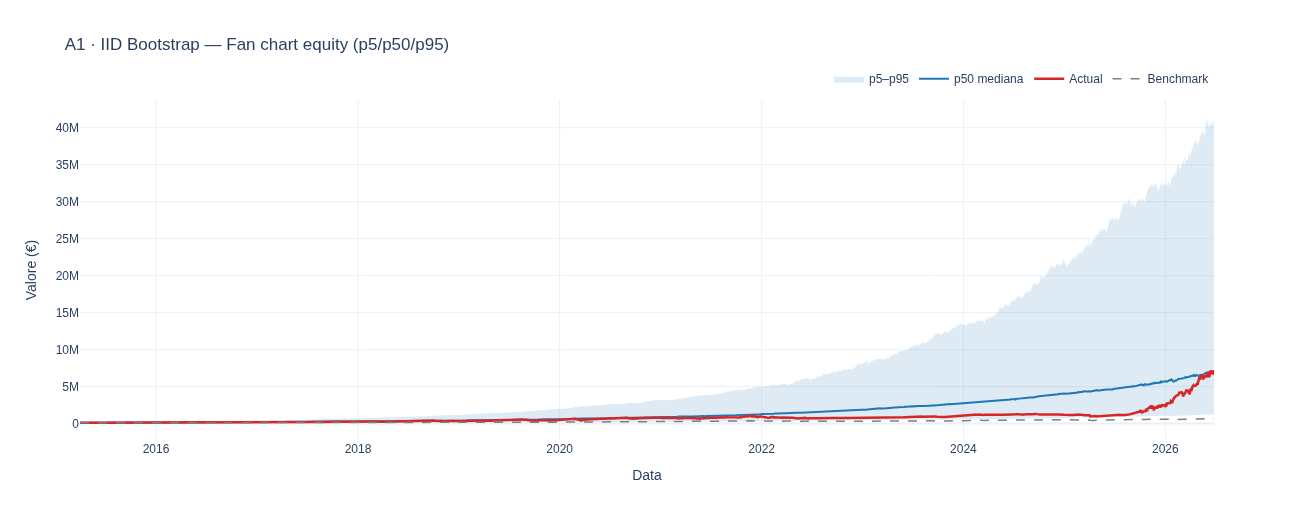

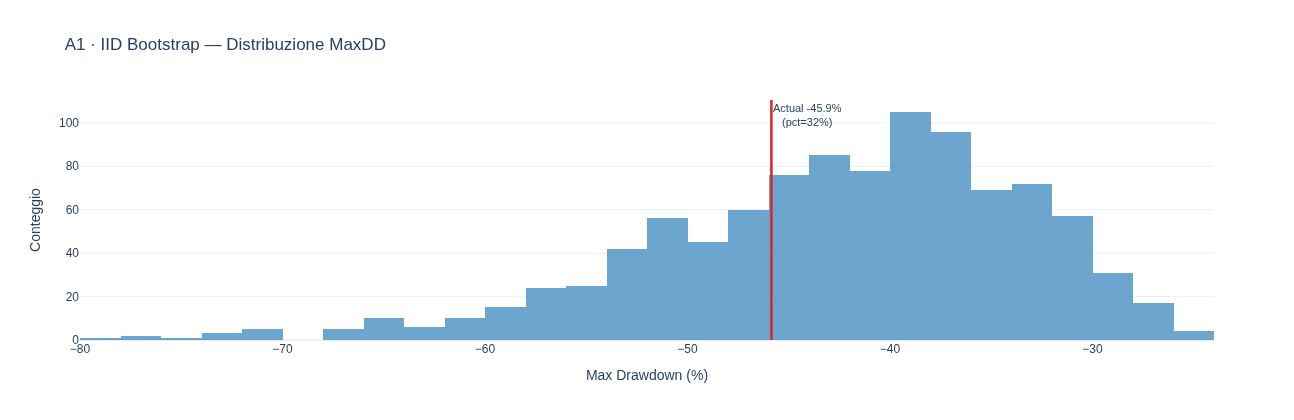

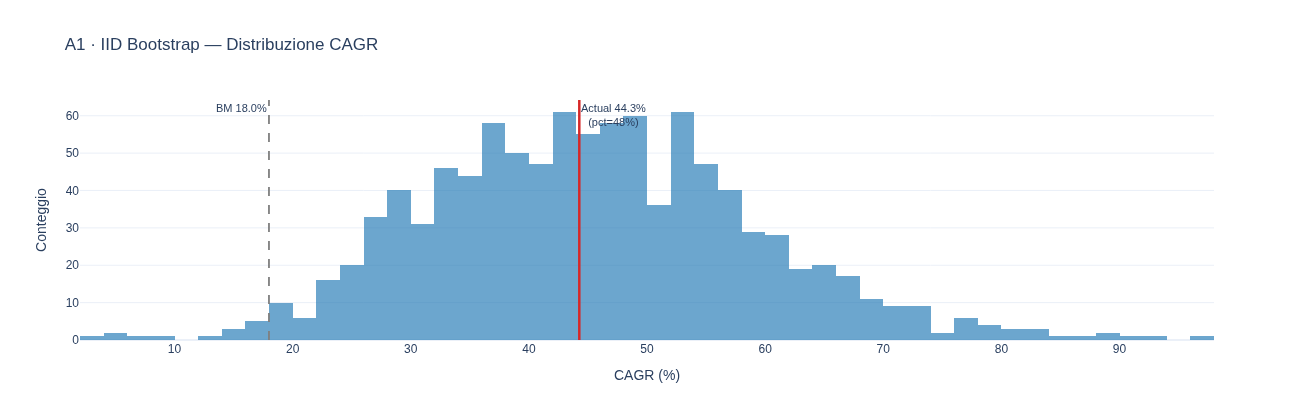

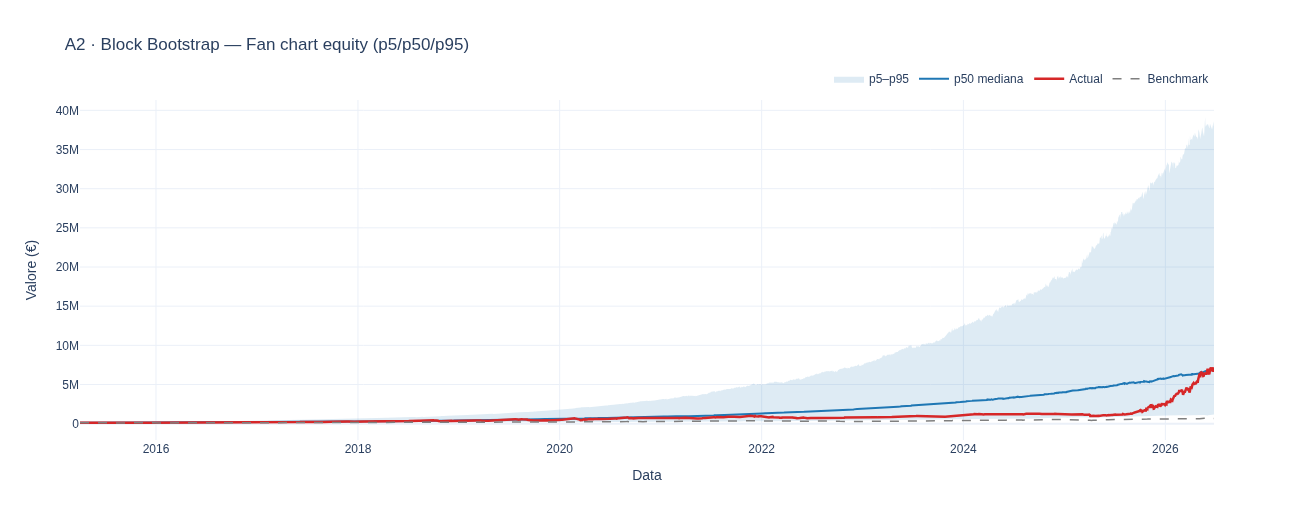

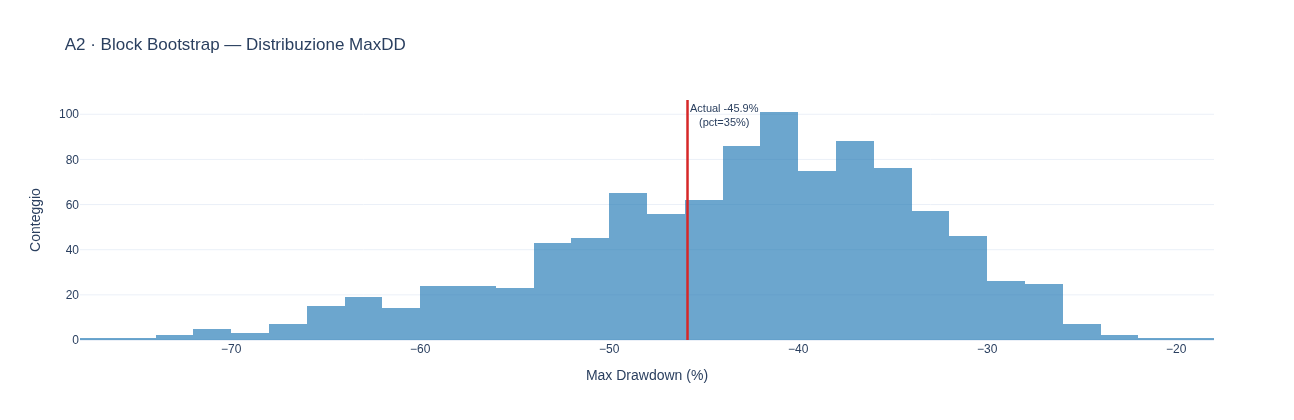

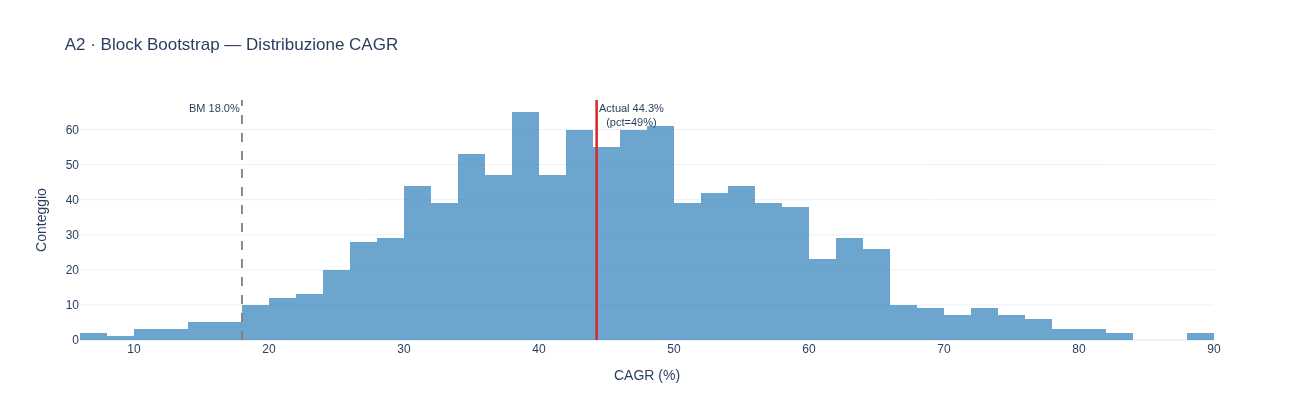

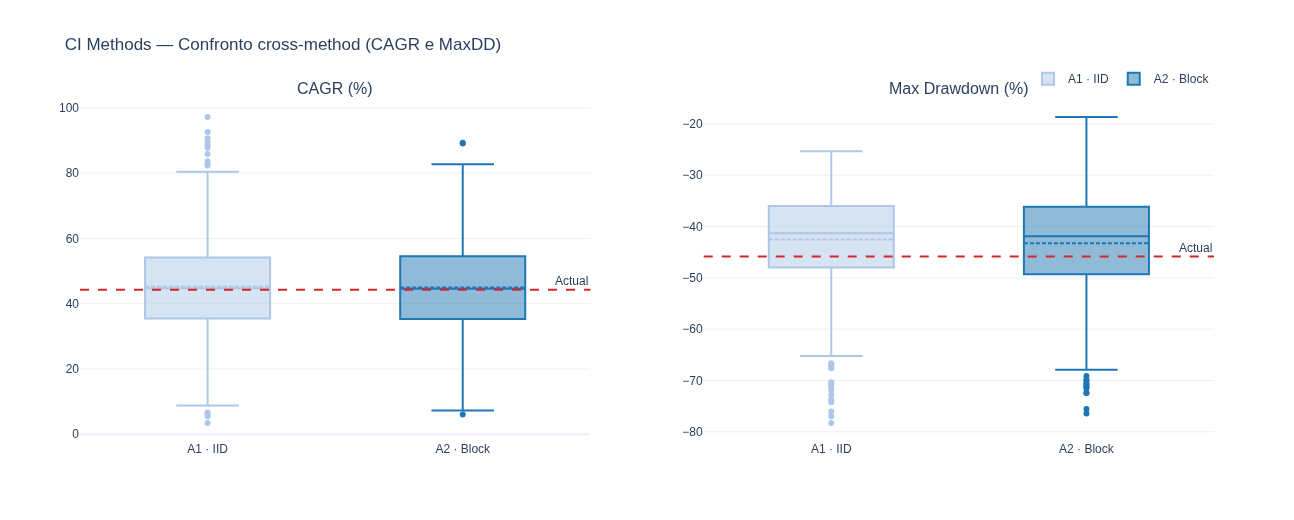


  [SRI/PRIIPs Cat.3]  IID=2  Block=2  Final=2  (T_eff=5.0y  capital=10,000 EUR)
BLOCCO B — Skill Tests (p-value)

▶ B1 · Rotation Reshuffle ...

▶ B2 · Rebalance Timing Bootstrap ...

───────────────────────────────────────────────────────
Skill Test Summary (p-value per metrica):

  B1 · Rotation Reshuffle
  → Selection skill: SIGNIFICANT (p_CAGR=0.000, p_Sharpe=0.013, p_Calmar=0.030)
    CAGR        : p=0.000***  actual=+0.478
    MaxDD       : p=0.860     actual=-0.459
    Sharpe      : p=0.013*    actual=+1.314
    Calmar      : p=0.030*    actual=+1.043

  B2 · Rebalance Timing
  → Timing skill: SIGNIFICANT (p_CAGR=0.008)
    CAGR        : p=0.008***  actual=+0.478
    MaxDD       : p=0.785     actual=-0.459
    Sharpe      : p=0.050     actual=+1.314
    Calmar      : p=0.090     actual=+1.043


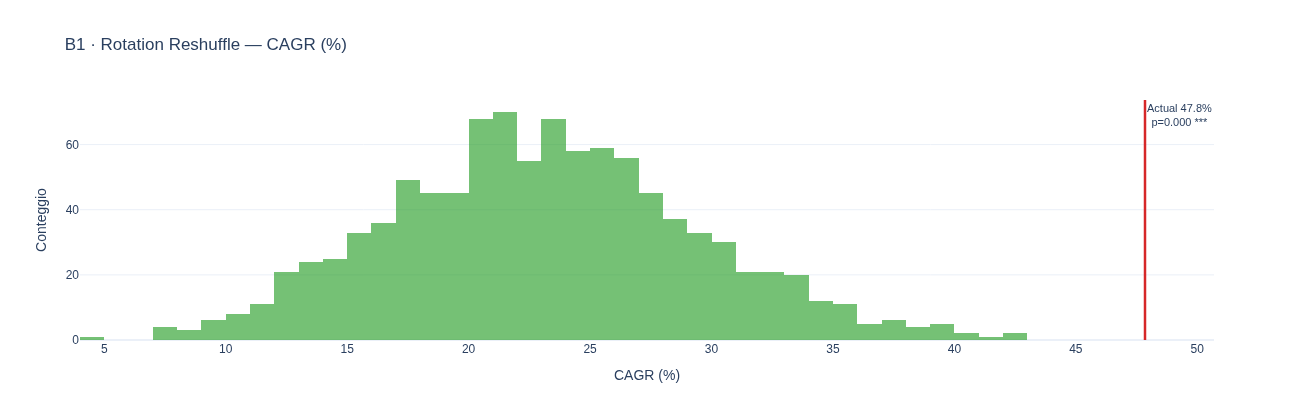

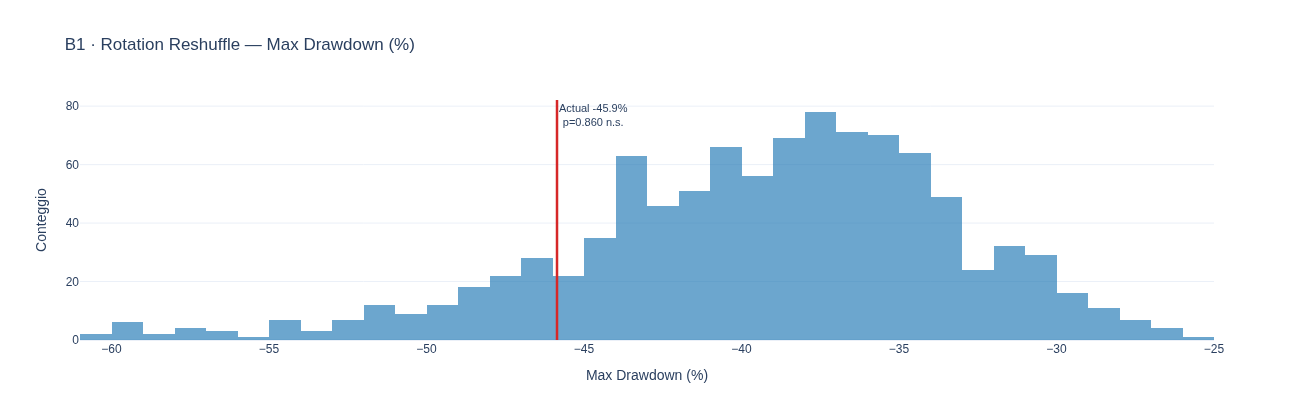

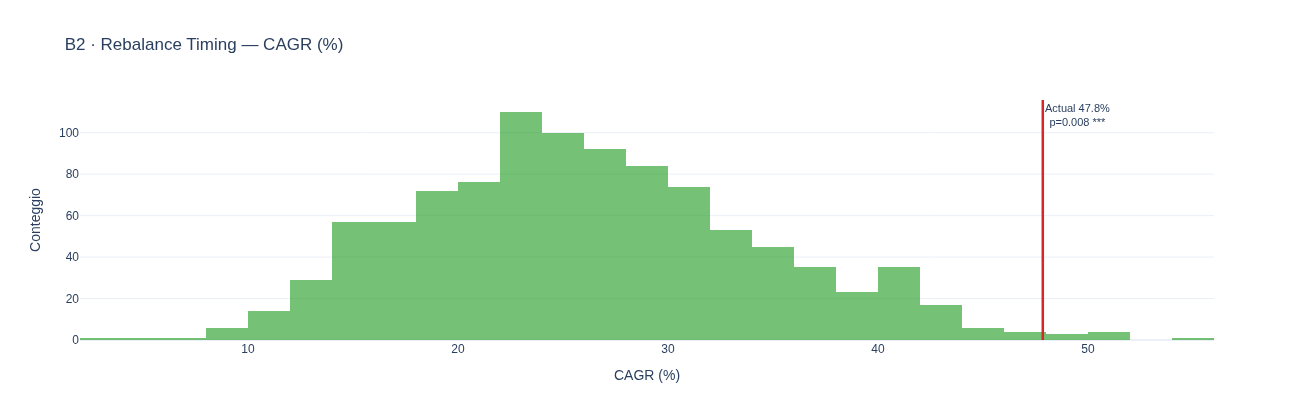

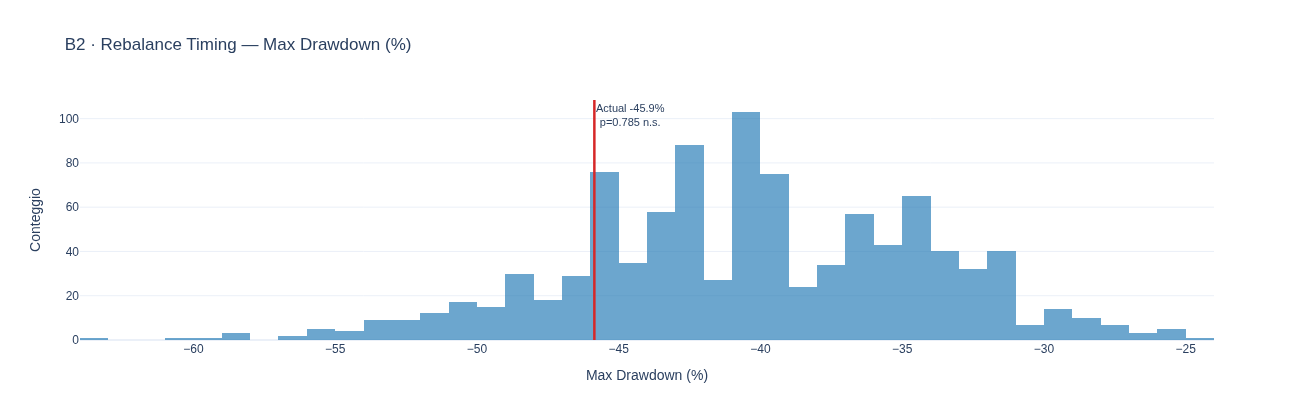

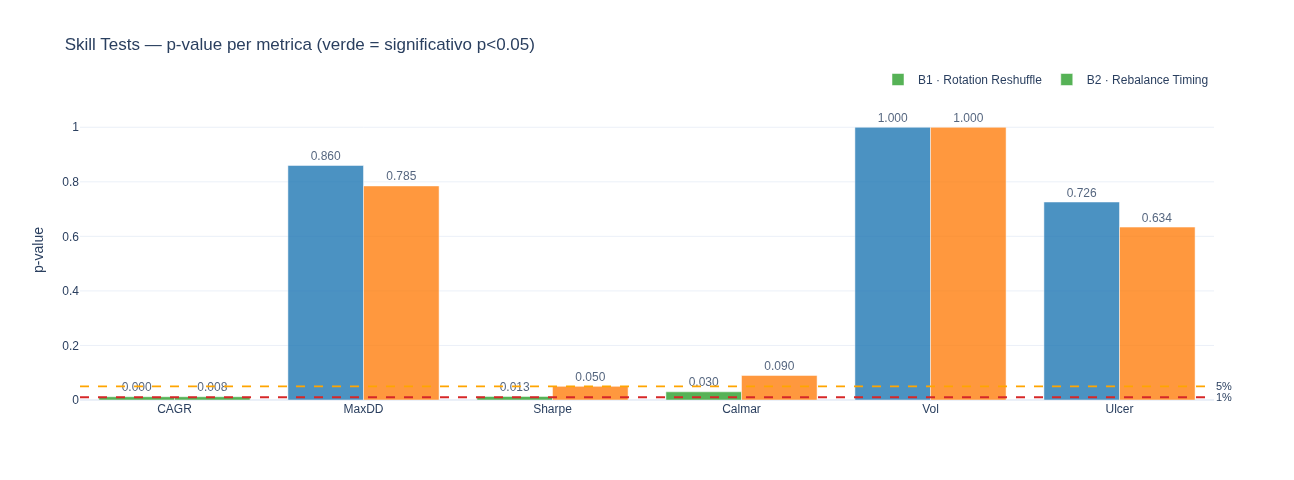

Reference portfolios for MC validation
  Blocco A: pf_rot       (with Risk ON/OFF)  MC-CAGR=0.2887 | vbt-CAGR=0.4440
  Blocco B: pf_rot_base  (no Risk ON/OFF)    MC-CAGR=0.3504 | vbt-CAGR=0.5452
  Note: MC uses (V_end/V_start)^(252/n)-1  (academic convention).
        vbt uses an internal annualization that differs systematically.
        Compare MC-Actual vs MC distributions only; do NOT mix vbt and MC values.
BLOCCO A — Confidence Intervals

▶ A1 · IID Bootstrap ...
  [A1 sanity] median_CAGR=0.284  actual_CAGR=0.289  bias=-0.0044 (should be ≈ 0)

▶ A2 · Block Bootstrap ...
  [A2 sanity] std_CAGR=0.0824  (block_size=10; confronta con A1 — A2 dovrebbe avere std >= A1)

▶ A3 · Regime-Conditional Block Bootstrap ...
  [A3 sanity] hist_risk_off=32.96%  risk_on=67.04%  (frazioni preservate per costruzione)  fallback_used=False
  [A3 sanity] abs(diff) OFF frac = 0.000 (garantito dall'algoritmo)

───────────────────────────────────────────────────────
CI Summary (p50 | Actual | Benchmark):



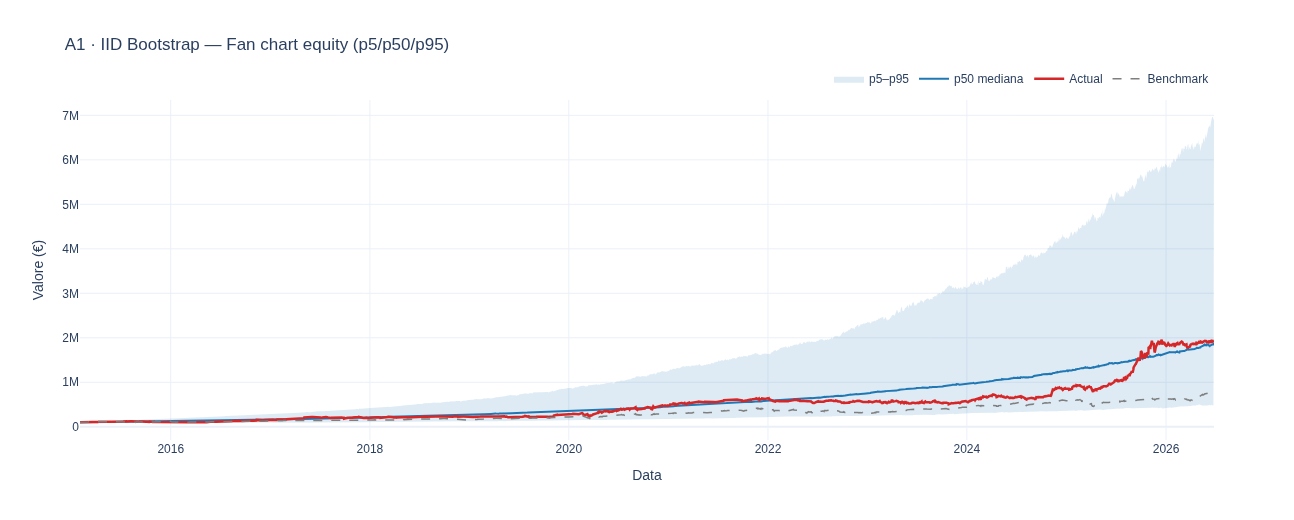

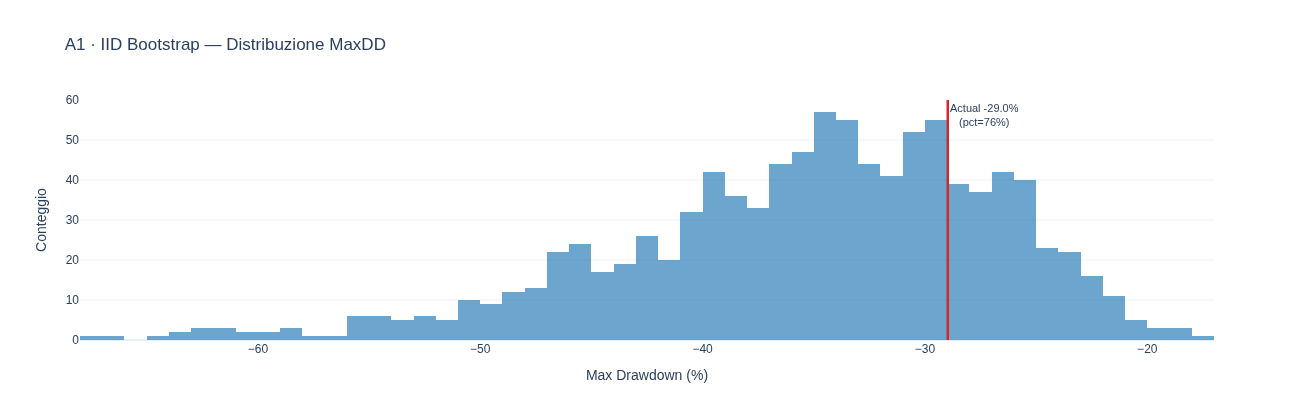

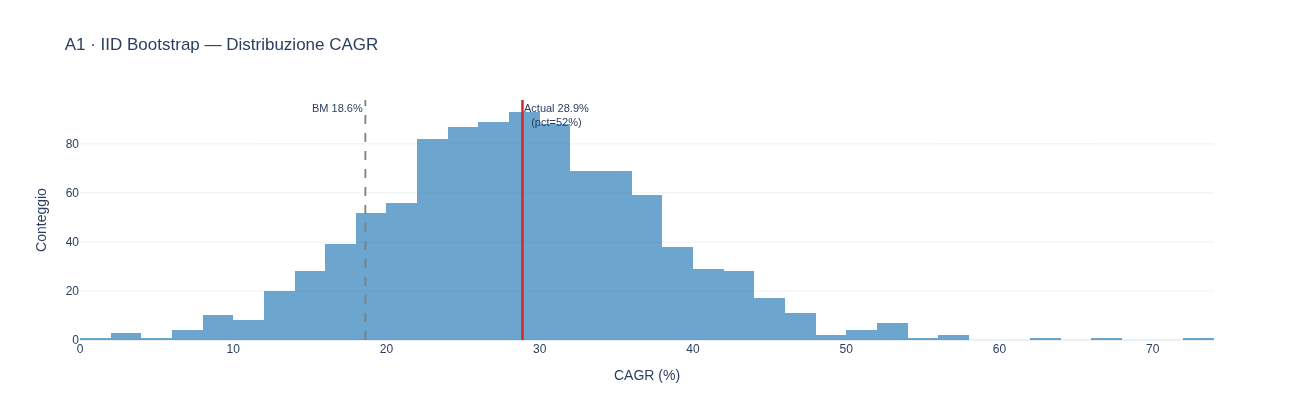

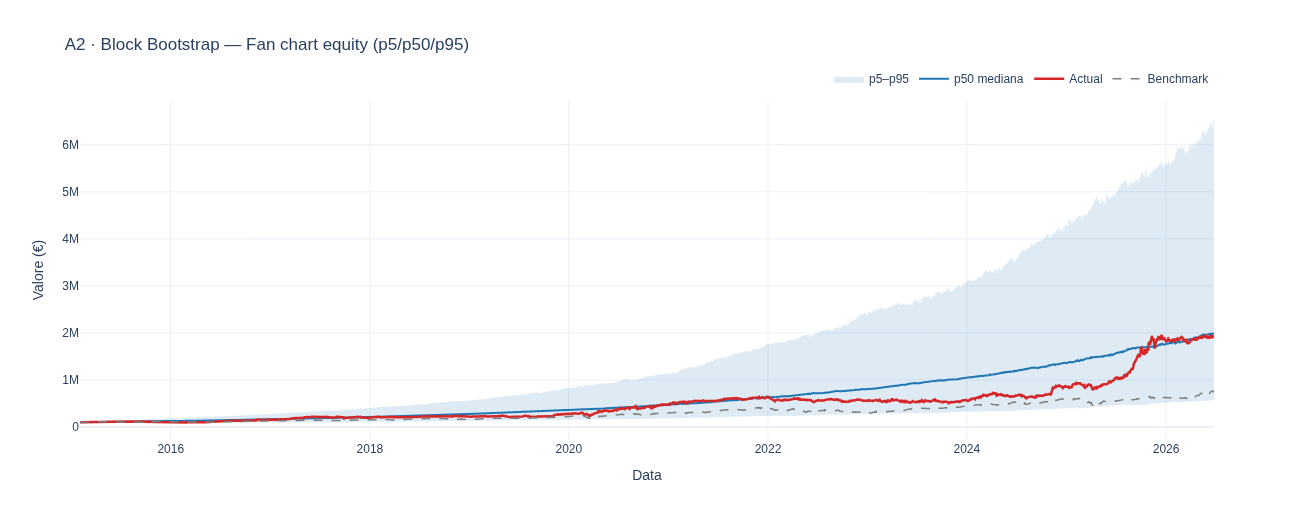

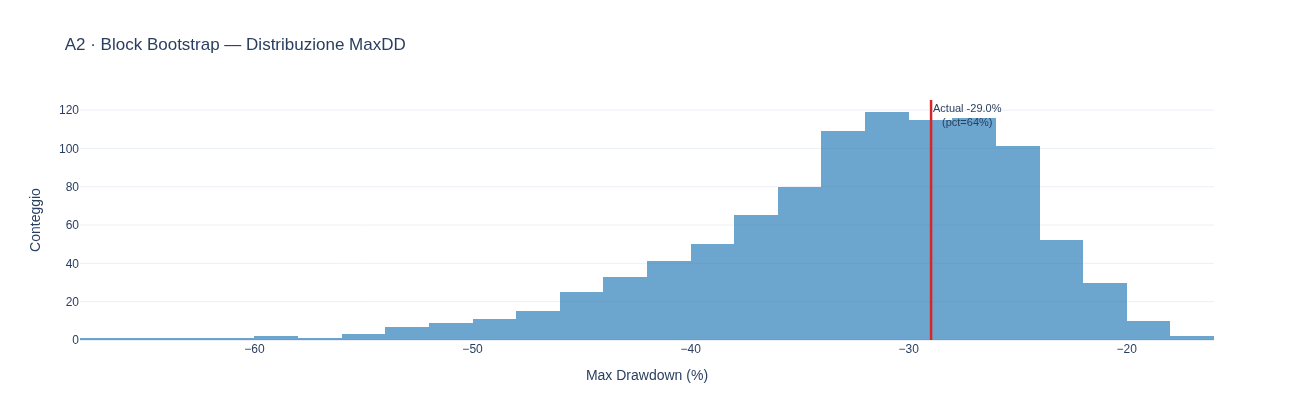

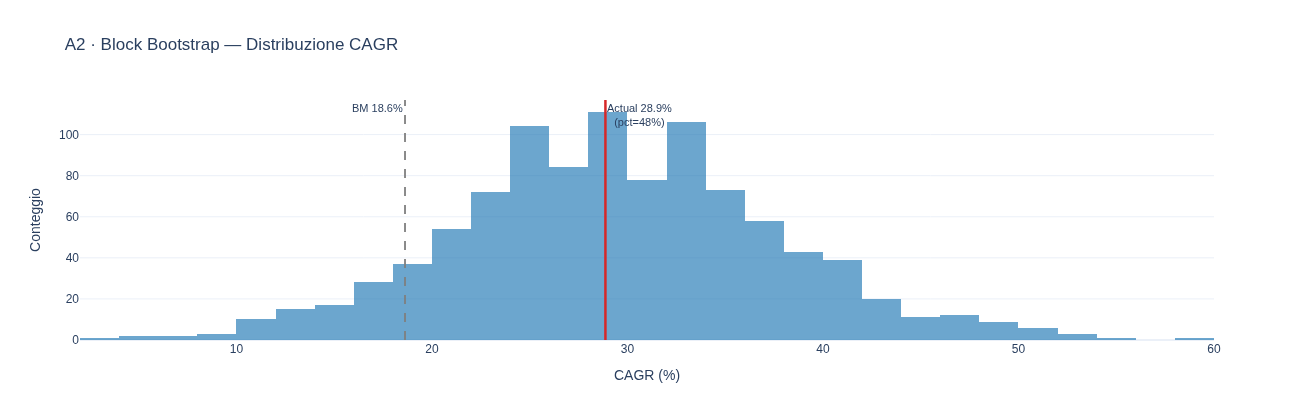

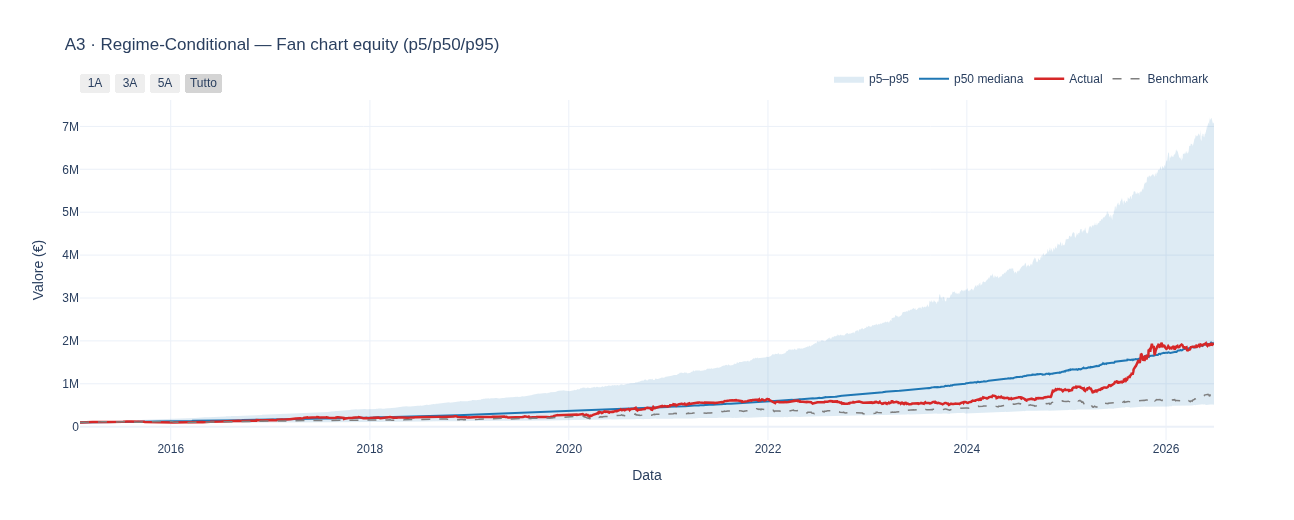

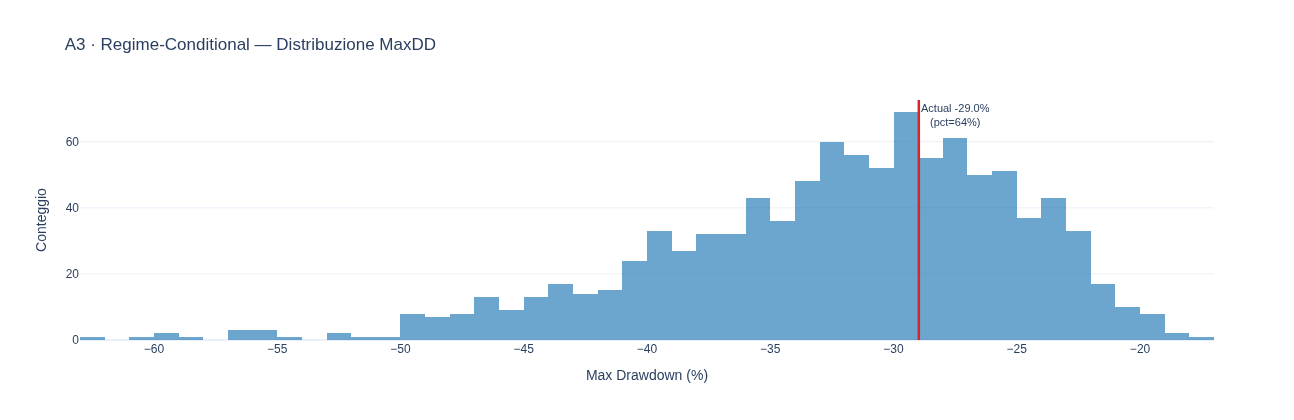

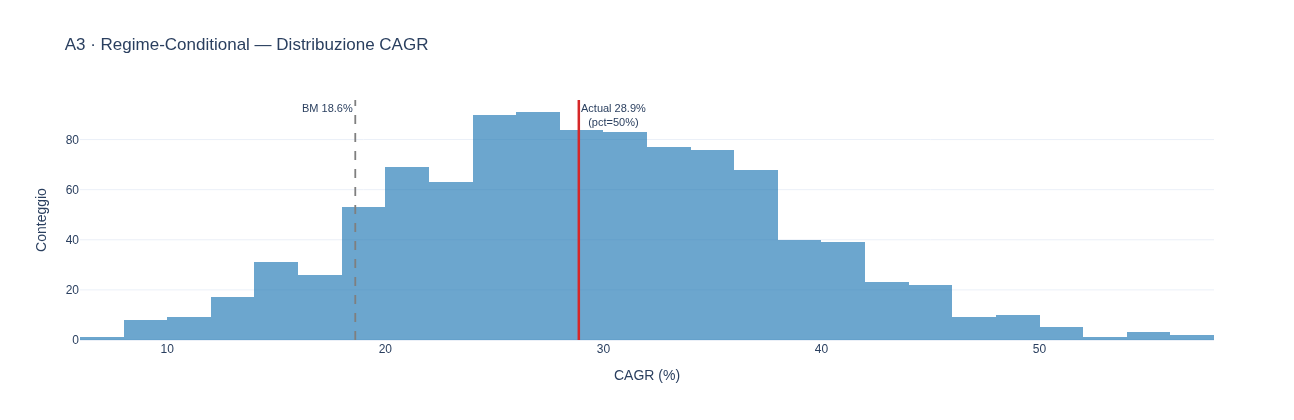

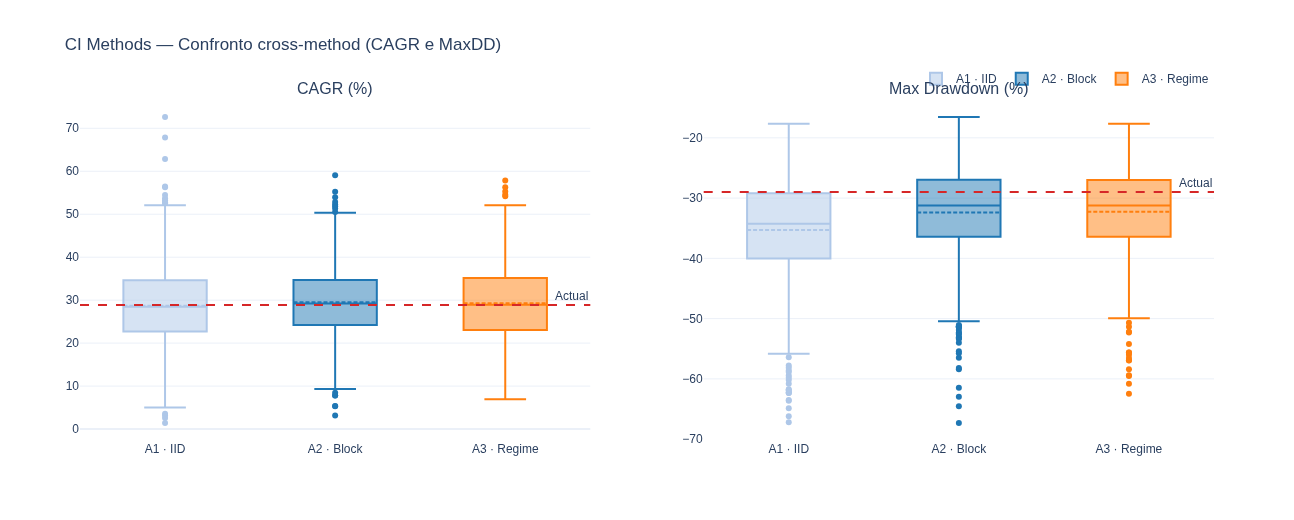


  [SRI/PRIIPs Cat.3]  IID=2  Block=2  Final=2  (T_eff=5.0y  capital=10,000 EUR)
BLOCCO B — Skill Tests (p-value)

▶ B1 · Rotation Reshuffle ...

▶ B2 · Rebalance Timing Bootstrap ...

───────────────────────────────────────────────────────
Skill Test Summary (p-value per metrica):

  B1 · Rotation Reshuffle
  → Selection skill: SIGNIFICANT (p_CAGR=0.002, p_Sharpe=0.005, p_Calmar=0.000)
    CAGR        : p=0.002***  actual=+0.350
    MaxDD       : p=0.000***  actual=-0.328
    Sharpe      : p=0.005***  actual=+1.263
    Calmar      : p=0.000***  actual=+1.067

  B2 · Rebalance Timing
  → Timing skill: NOT significant (p_CAGR=0.261)
    CAGR        : p=0.261     actual=+0.350
    MaxDD       : p=0.028*    actual=-0.328
    Sharpe      : p=0.089     actual=+1.263
    Calmar      : p=0.094     actual=+1.067


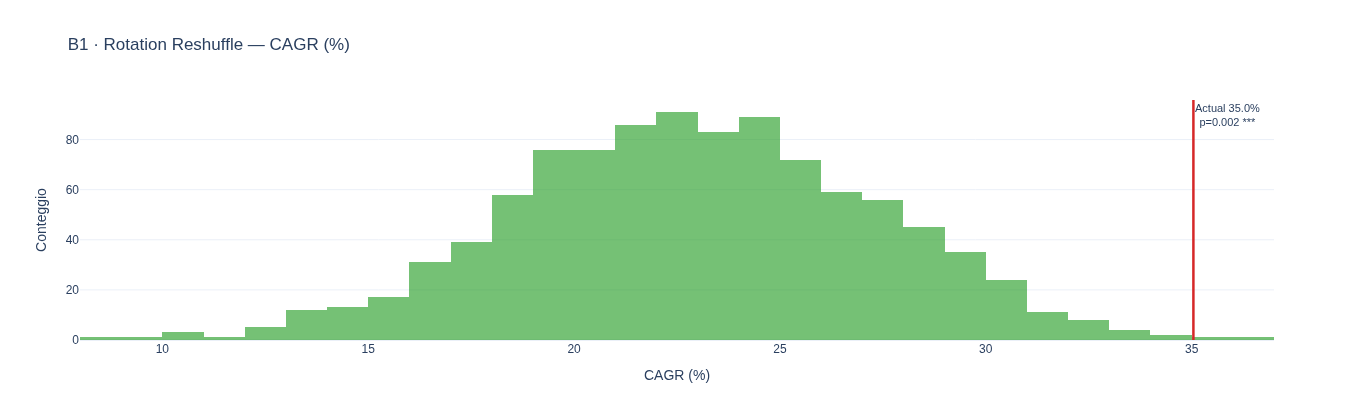

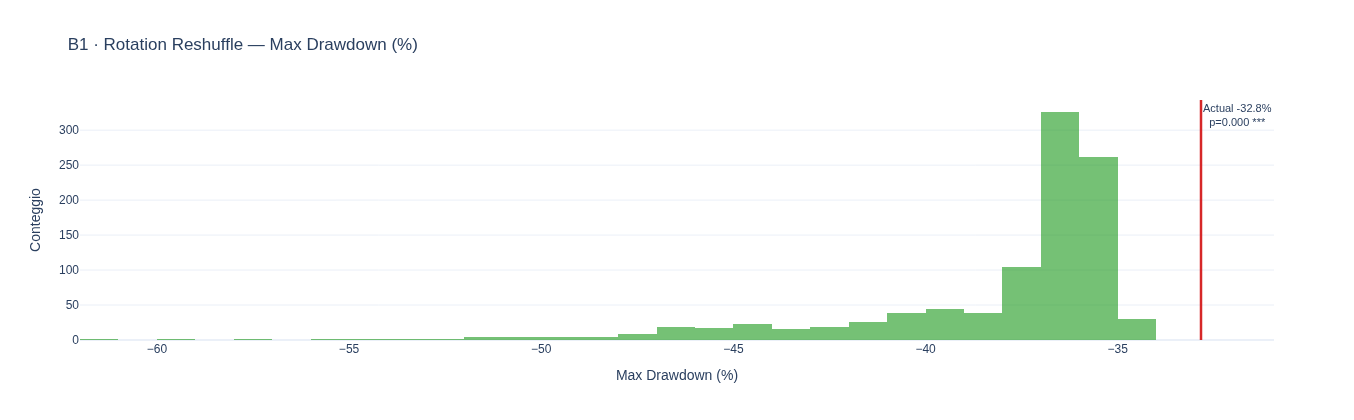

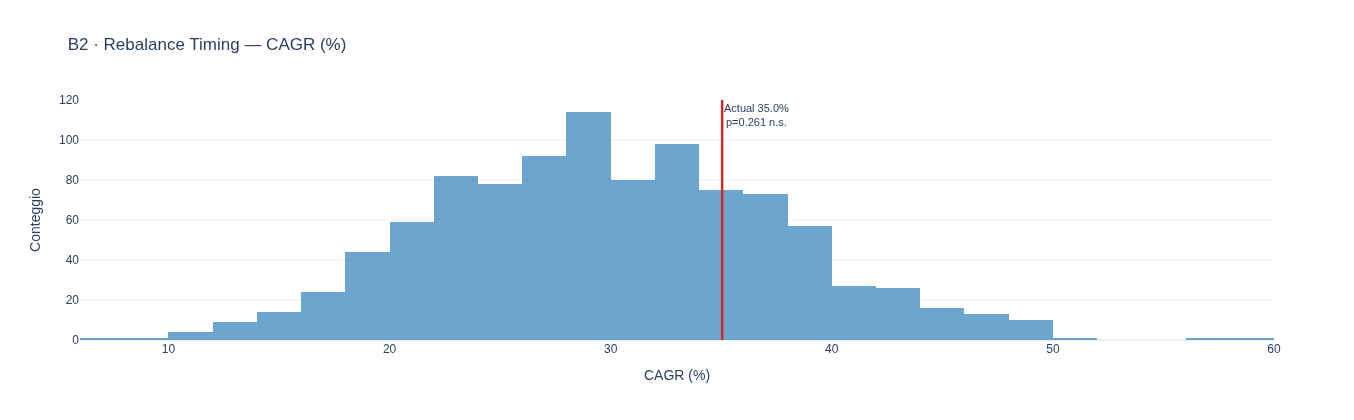

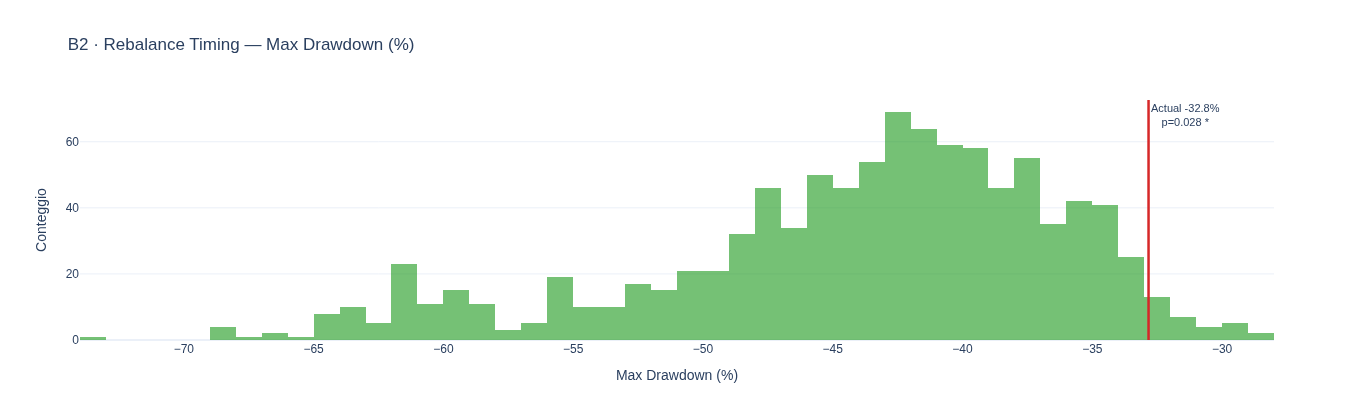

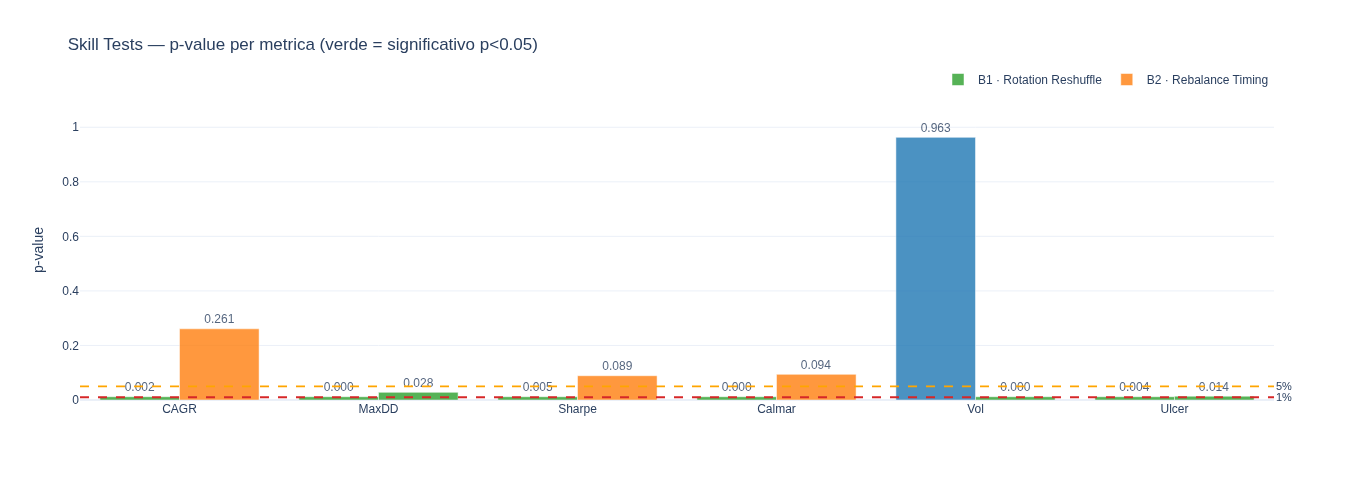

In [27]:

from pathlib import Path

# Sub-directory per i plot dei due path (evita sovrascrittura)
plots_dir_std     = Path(plots_dir) / 'std'
plots_dir_cluster = Path(plots_dir) / 'cluster'
plots_dir_std.mkdir(parents=True, exist_ok=True)
plots_dir_cluster.mkdir(parents=True, exist_ok=True)

# Run completa (n=1000) con grafici — Path Standard
ci_results, ci_summary_df, skill_results, skill_summary_df = run_all_mc_methods_rotational(
    pf_rot              = pf_rot_std,
    pf_rot_base         = pf_rot_std_base,
    regime              = regime,
    sel_tickers         = sel_tickers_std,
    sel_tickers_base    = sel_tickers_std_base,
    stocks_data         = stocks_data,
    benchmark_data      = benchmark_data,
    tickers_master      = tickers,
    init_cash           = init_cash,
    n_simulations       = 1000,
    seed                = 42,
    block_size          = 10,
    vol_window          = 60,
    n_vol_quantiles     = 3,
    show_method_plots   = True,
    show_method_summaries = True,
    save_plots            = True,
    plots_dir             = plots_dir_std,   # ← sub-dir Standard
)

# Run completa (n=1000) con grafici — Path Cluster
if pf_rot_cluster is not None and pf_rot_cluster_base is not None:
    ci_results_cluster, ci_summary_df_cluster, skill_results_cluster, skill_summary_df_cluster = run_all_mc_methods_rotational(
        pf_rot              = pf_rot_cluster,
        pf_rot_base         = pf_rot_cluster_base,
        regime              = regime_cluster,
        sel_tickers         = sel_tickers_cluster,
        sel_tickers_base    = sel_tickers_cluster_base,
        stocks_data         = stocks_data,
        benchmark_data      = benchmark_data,
        tickers_master      = tickers,
        init_cash           = init_cash,
        n_simulations       = 1000,
        seed                = 42,
        block_size          = 10,
        vol_window          = 60,
        n_vol_quantiles     = 3,
        show_method_plots   = True,
        show_method_summaries = True,
        save_plots            = True,
        plots_dir             = plots_dir_cluster,   # ← sub-dir Cluster
    )
else:
    ci_results_cluster        = None
    ci_summary_df_cluster     = None
    skill_results_cluster     = None
    skill_summary_df_cluster  = None

In [28]:
display(ci_summary_df)
display(skill_summary_df)
display(ci_summary_df_cluster)
display(skill_summary_df_cluster)

,CAGR_p5,MaxDD_p5,Sharpe_p5,Calmar_p5,Volatility_p5,Ulcer_p5,CAGR_p25,MaxDD_p25,Sharpe_p25,Calmar_p25,...,Benchmark_Sharpe,Benchmark_Calmar,Benchmark_Volatility,Benchmark_Ulcer,Actual_base_CAGR,Actual_base_MaxDD,Actual_base_Sharpe,Actual_base_Calmar,Actual_base_Volatility,Actual_base_Ulcer
Method,,,,,,,,,,,,,,,,,,,,,
A1 · IID Bootstrap,0.244655,-0.588726,0.824425,0.464413,0.312584,-0.232860,0.354970,-0.479663,1.089928,0.772450,...,0.90728,0.576974,0.20596,-0.093701,0.478474,-0.458568,1.313927,1.043408,0.342433,-0.134834
A2 · Block Bootstrap,0.236464,-0.623152,0.805860,0.431882,0.303923,-0.239142,0.353276,-0.492851,1.086271,0.747399,...,0.90728,0.576974,0.20596,-0.093701,0.478474,-0.458568,1.313927,1.043408,0.342433,-0.134834


,p_value_CAGR,p_value_MaxDD,p_value_Sharpe,p_value_Calmar,p_value_Volatility,p_value_Ulcer,Actual_CAGR,Actual_MaxDD,Actual_Sharpe,Actual_Calmar,Actual_Volatility,Actual_Ulcer,interpretation
Test,,,,,,,,,,,,,
B1 · Rotation Reshuffle,0.000,0.860,0.013,0.03,1.0,0.726,0.478474,-0.458568,1.313927,1.043408,0.342433,-0.134834,"Selection skill: SIGNIFICANT (p_CAGR=0.000, p_..."
B2 · Rebalance Timing,0.008,0.785,0.050,0.09,1.0,0.634,0.478474,-0.458568,1.313927,1.043408,0.342433,-0.134834,Timing skill: SIGNIFICANT (p_CAGR=0.008)


,CAGR_p5,MaxDD_p5,Sharpe_p5,Calmar_p5,Volatility_p5,Ulcer_p5,CAGR_p25,MaxDD_p25,Sharpe_p25,Calmar_p25,...,Benchmark_Sharpe,Benchmark_Calmar,Benchmark_Volatility,Benchmark_Ulcer,Actual_base_CAGR,Actual_base_MaxDD,Actual_base_Sharpe,Actual_base_Calmar,Actual_base_Volatility,Actual_base_Ulcer
Method,,,,,,,,,,,,,,,,,,,,,
A1 · IID Bootstrap,0.144704,-0.506376,0.682481,0.313428,0.231165,-0.204746,0.227412,-0.400171,0.971519,0.574074,...,0.935413,0.597052,0.205279,-0.093063,0.350424,-0.328333,1.262939,1.067282,0.266107,-0.083181
A2 · Block Bootstrap,0.161070,-0.462471,0.727783,0.399597,0.226711,-0.171854,0.242401,-0.364025,1.022936,0.682029,...,0.935413,0.597052,0.205279,-0.093063,0.350424,-0.328333,1.262939,1.067282,0.266107,-0.083181
A3 · Regime-Conditional,0.150214,-0.461015,0.709966,0.383207,0.227852,-0.175435,0.230875,-0.364039,0.984330,0.657465,...,0.935413,0.597052,0.205279,-0.093063,0.350424,-0.328333,1.262939,1.067282,0.266107,-0.083181


,p_value_CAGR,p_value_MaxDD,p_value_Sharpe,p_value_Calmar,p_value_Volatility,p_value_Ulcer,Actual_CAGR,Actual_MaxDD,Actual_Sharpe,Actual_Calmar,Actual_Volatility,Actual_Ulcer,interpretation
Test,,,,,,,,,,,,,
B1 · Rotation Reshuffle,0.002,0.000,0.005,0.000,0.963,0.004,0.350424,-0.328333,1.262939,1.067282,0.266107,-0.083181,"Selection skill: SIGNIFICANT (p_CAGR=0.002, p_..."
B2 · Rebalance Timing,0.261,0.028,0.089,0.094,0.000,0.014,0.350424,-0.328333,1.262939,1.067282,0.266107,-0.083181,Timing skill: NOT significant (p_CAGR=0.261)


## §8 — Decisione finale + Scheda PTF

Aggrega tutti i segnali in una tabella decisionale per path.
L'ultima riga "User decision" è compilata a mano dal modellista.

In [29]:
# STEP 8 — Decisione finale + Scheda PTF + Relazione Tecnica

from datetime import date
_today_iso = date.today().isoformat()

# Output paths — stessa struttura e naming del CLI (no sottocartelle extra,
# no doppio livello data: reports_dir è già <root>/outputs/reports/<ptf>/<data>/)
_ptf_name = portfolio_title.replace(' ', '_').lower()
_card_path = reports_dir / f"{_ptf_name}_{year}_{profile}.md"
_pdf_path  = reports_dir / f"{portfolio_title}_{year}_{profile}_Relazione_Tecnica.pdf"
_card_path.parent.mkdir(parents=True, exist_ok=True)
_pdf_path.parent.mkdir(parents=True, exist_ok=True)



skill_profile_std, skill_profile_cluster = compute_skill_profile(
    mc_skill=skill_results,
    mc_skill_cluster=skill_results_cluster,
)

# Compat: per ora il parametro skill_profile passato a generate_relazione_tecnica 
# resta singolo. Useremo skill_profile_std come default; lo sdoppiamento avverrà 
# nella firma di generate_relazione_tecnica al pezzo 4.
skill_profile = skill_profile_std

_wfo_config = {
    'ratio':            ratio,
    'metric':           metric,
    'n_full_trials':    n_full_trials,
    'n_reduced_trials': n_reduced_trials,
    'wfo_file_save':    wfo_file_save,
    'use_clustering':   use_clustering,
    'n_bootstrap_ofc':  1000,
    'n_bootstrap_mc':   1000,
}

_cluster_result = (
    results_cluster.get('cluster_result') if results_cluster else None
)

_metrics_comparison = {
    'cluster_riskoff': results_cluster.get('pf_rot')      if results_cluster else None,
    'cluster_base':    results_cluster.get('pf_rot_base') if results_cluster else None,
    'std_riskoff':     results_std.get('pf_rot'),
    'std_base':        results_std.get('pf_rot_base'),
    'benchmark':       results_std.get('pf_benchmark') or results_std.get('pf_benchmark_base'),
}


# 1. Stampa DECISIONE FINALE a video
print_final_decision(
    portfolio_title    = portfolio_title,
    year               = year,
    profile            = profile,
    ofc_report_std     = ofc_report_std,
    ofc_report_cluster = ofc_report_cluster,
    mc_skill           = skill_results,
    mc_ci              = ci_summary_df,
    skill_profile      = skill_profile,
    mc_skill_cluster   = skill_results_cluster,     # NEW
    mc_ci_cluster      = ci_summary_df_cluster,     # NEW
)

# 2. Scrivi PTF Card markdown
generate_ptf_card_md(
    portfolio_title    = portfolio_title,
    year               = year,
    profile            = profile,
    benchmark          = benchmark_title,
    period             = (str(pipeline_start_date), _today_iso),
    universe_size      = len(tickers),
    wfo_config         = _wfo_config,
    cluster_result     = _cluster_result,
    metrics_comparison = _metrics_comparison,
    ofc_report_std     = ofc_report_std,
    ofc_report_cluster = ofc_report_cluster,
    mc_skill           = skill_results,
    mc_ci              = ci_summary_df,
    mc_skill_cluster = skill_results_cluster,        # NEW
    mc_ci_cluster    = ci_summary_df_cluster,        # NEW
    skill_profile      = skill_profile,
    output_path        = _card_path,
)
print(f"PTF Card MD: {_card_path}")

# 3. Genera scheda tecnica PDF
generate_relazione_tecnica(
    portfolio_title              = portfolio_title,
    year                         = year,
    profile                      = profile,
    benchmark                    = benchmark_title,
    period                       = (str(pipeline_start_date), _today_iso),
    universe_size                = len(tickers),
    wfo_config                   = _wfo_config,
    cluster_result               = _cluster_result,
    metrics_comparison           = _metrics_comparison,
    ofc_report_std               = ofc_report_std,
    ofc_report_cluster           = ofc_report_cluster,
    mc_skill                     = skill_results,
    mc_ci                        = ci_summary_df,
    skill_profile                = skill_profile_std,            # B-005: ex skill_profile
    skill_profile_cluster        = skill_profile_cluster,        # B-005: nuovo
    plots_dir                    = plots_dir,
    output_path                  = _pdf_path,
    ci_results                   = ci_results,
    mc_skill_cluster             = skill_results_cluster,        # passato come prima
    mc_ci_cluster                = ci_summary_df_cluster,        # passato come prima
    survivorship_bias_universe   = survivorship_bias_universe,
)

print(f"Relazione tecnica PDF: {_pdf_path}")

  DECISIONE FINALE — Alpha Nasdaq100 (2026) — profile=satellite
          Signal WFO STANDARD  WFO CLUSTER
      S1 plateau         PASS         PASS
    S2 coherence         FAIL         PASS
   S3 random sel         PASS         FAIL
          S4 DSR         PASS         PASS
  MC Reshuffle p p=0.000 PASS p=0.002 PASS
MC CI Sharpe p50        1.294        1.155
     OFC Verdict         PASS         PASS
   Skill profile       Strong             
  User decision: quale path deployare? [ STANDARD | CLUSTER | NESSUNO ]
  (compilare a mano nella scheda PTF con motivazione)
PTF Card MD: ../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/alpha_nasdaq100_2026_satellite.md
🛠️ Analisi Portfolio Rotazionale (Portafoglio Rotazionale):

Relazione tecnica PDF: ../../outputs/r_analysis/alpha_nasdaq100/20260626_160201/Alpha Nasdaq100_2026_satellite_Relazione_Tecnica.pdf


In [30]:
# §8 — Salvataggio WFO per il RUNTIME (path scelto dall'architetto)
#
# fix/r-runtime-save-chosen-path:
# Questa cella scrive su `wfo_file_save` — l'UNICO file letto da r_run_portfolio
# nel runtime (via collect_selections_from_summary +
# extract_operational_params_from_summary) — il summary_df del path
# EFFETTIVAMENTE scelto qui in §8.
#
# Compilare `path_scelto` a mano DOPO aver letto la relazione tecnica PDF.

path_scelto = "CLUSTER"   # "STANDARD" oppure "CLUSTER" — compilare a mano dopo lettura PDF

_path_scelto = str(path_scelto).strip().upper()
if _path_scelto not in ("STANDARD", "CLUSTER"):
    raise ValueError(
        f"path_scelto non valido: '{path_scelto}'. Valori attesi: 'STANDARD' o 'CLUSTER'."
    )

if _path_scelto == "CLUSTER":
    if results_cluster is None:
        raise RuntimeError(
            "path_scelto='CLUSTER' ma results_cluster is None: il path Cluster non e' "
            "stato eseguito (§5b — WFO Clusterizzata). Esegui il WFO Cluster prima di "
            "salvare, oppure imposta path_scelto='STANDARD'."
        )
    _summary_df_runtime = summary_df_cluster
    _param_grid_runtime = full_grid       # il path Cluster usa full_grid (no stability)
else:
    _summary_df_runtime = summary_df_std
    _param_grid_runtime = reduced_grid    # il path Standard usa la reduced_grid (stability)

save_rotational_wfo_summary(
    summary_df             = _summary_df_runtime,
    start_date             = start_date,
    end_date               = end_date,
    file_path              = wfo_file_save,
    param_grid             = _param_grid_runtime,
    metric                 = metric,
    ratio                  = ratio,
    force_next_year_params = force_next_year_params,
    extra_meta             = {"deployed_path": _path_scelto},
)
print(f"[§8] Path scelto per il RUNTIME: {_path_scelto}")
print(f"[§8] WFO summary salvato su (letto da r_run_portfolio): {wfo_file_save}")

[WFO SAVE OK] File salvato correttamente: '../../outputs/WFO_R_DEV_RESULTS/Alpha Nasdaq100_2026.wfo_summary.csv' | Righe: 13 | Metric: Sharpe Ratio | Ratio: 3:1 | Data start: 2015-01-01 | Data end: None | Force next year params: True
[§8] Path scelto per il RUNTIME: CLUSTER
[§8] WFO summary salvato su (letto da r_run_portfolio): ../../outputs/WFO_R_DEV_RESULTS/Alpha Nasdaq100_2026.wfo_summary.csv


## §9 — Performance

In [ ]:
# Ci sono 4 portafogli disponibili:
# pf_rot_std_base        (WFO non clusterizzata)
# pf_rot_std             (WFO non clusterizzata, Risk ON/OFF)
# pf_rot_cluster_base    (WFO clusterizzata)
# pf_rot_cluster         (WFO clusterizzata, Risk ON/OFF)

# E per ognuno di essi 2 possibili confronto con altrettanti benchmark
# Benchmark esterno: definito dal portafoglio (benchmark_data=benchmark_data)
# Benchmark interno: B&H intero universo  (benchmark_data=None)

# Schema decisionale rapido                                                                                                      
                                                                                                                             
# Universo piccolo/omogeneo?
#   ├─ Sì → std_base  (o std se vuoi protezione drawdown)                                                                        
#   └─ No (grande/eterogeneo) → cluster_base  (o cluster se vuoi regime switching)                                               
                                                                                                                             
# Vuoi ridurre il max drawdown?                                                                                                  
#   └─ Sì → aggiungi Risk ON/OFF (std → std_on, cluster → cluster_on)                                                            
                                                                                                                             
# Periodo OOS corto (<3 anni)?
#   └─ Preferisci la versione _base: meno parametri, più robusta                                                                 
                                                                                                                             
# ---
# In pratica, pf_rot_cluster è il più potente ma anche il più fragile se i dati sono pochi. pf_rot_std_base è il più stabile e   
# interpretabile. Gli altri due stanno nel mezzo.                                                                                

pf = pf_rot_cluster
sel_tickers = sel_tickers_cluster

out = generate_rotational_portfolio_performance(
    pf=pf,
    portfolio_title=portfolio_title,
    sel_tickers=sel_tickers,
    benchmark=benchmark_title,
    benchmark_data=benchmark_data,   # prezzi close
    alpha_analysis=True,
    show_plots=True,
    plot_start_date='2026-05-11'
)

In [ ]:
# Engine Sanity Check
health_df, ticker_df, selection_log, details = build_engine_health_check(
    pf_rot_std,
    sel_tickers_std,
    prices    = stocks_data,
    start_date = start_date,
    end_date   = end_date,
    include_prev = True,
)
my_display(health_df, "Health check motore rotazionale")
my_display(selection_log, "Audit selezioni")

## §10 — Load WFO Results

Riprende un'analisi precedente senza rieseguire WFO, stability e OFC.
Richiede che §4 abbia salvato `stability_report.csv` e §6 abbia salvato `ofc_report.json`.

In [ ]:
# Carica wfo_summary, stability_report e ofc_report da run precedente
import json
import os

summary_df       = load_wfo_summary(wfo_file_save)

stability_report_path   = reports_dir / f"{portfolio_title}_{year}_stability.csv"
ofc_report_std_path     = reports_dir / f"{portfolio_title}_{year}_ofc_std.json"

if os.path.exists(stability_report_path):
    stability_report = pd.read_csv(stability_report_path)
    print(f"Stability report caricato: {stability_report_path}")
else:
    stability_report = None
    print(f"[WARN] stability report non trovato: {stability_report_path}")

if os.path.exists(ofc_report_std_path):
    with open(ofc_report_std_path) as f:
        ofc_report_std = json.load(f)
    print(f"OFC report std caricato: {ofc_report_std_path}")
else:
    ofc_report_std = None
    print(f"[WARN] OFC report std non trovato: {ofc_report_std_path}")

display(summary_df)

In [ ]:
# Ricostruisce pf_rot e sel_tickers dalla wfo_summary caricata
# Sostituisce la chiamata stale build_rotational_portfolios_from_wfo_result
pf_rot, pf_bh, sel_tickers = build_portfolio_from_wfo_summary(
    summary_df     = summary_df,
    stocks_data    = stocks_data,
    benchmark_data = benchmark_data,
    start_date     = start_date,
    end_date       = end_date,
    benchmark_title = benchmark_title,
    portfolio_name  = portfolio_title,
    init_cash       = init_cash,
    plot            = True,
    show_report     = True,
)

In [ ]:
# Ricostruisce pf_rot e sel_tickers dalla wfo_summary caricata
# Sostituisce la chiamata stale build_rotational_portfolios_from_wfo_result
pf_rot, pf_bh, sel_tickers = build_portfolio_from_wfo_summary(
    summary_df     = summary_df_cluster,
    stocks_data    = stocks_data,
    benchmark_data = benchmark_data,
    start_date     = start_date,
    end_date       = end_date,
    benchmark_title = benchmark_title,
    portfolio_name  = portfolio_title,
    init_cash       = init_cash,
    plot            = True,
    show_report     = True,
)

In [ ]:
# Dopo il load e' possibile eseguire §8 (Decisione finale) ricalcolando
# le variabili derivate da ofc_report_std e skill_results se disponibili.
# Oppure ri-eseguire §7 (MC) senza rieseguire il WFO.
print("Load completato. Variabili disponibili:")
print(f"  summary_df:       {summary_df.shape}")
print(f"  pf_rot:           {type(pf_rot).__name__}")
print(f"  sel_tickers:      {sel_tickers.shape}")
print(f"  stability_report: {'OK' if stability_report is not None else 'non disponibile'}")
print(f"  ofc_report_std:   {'OK' if ofc_report_std is not None else 'non disponibile'}")

## Snapshot

In [ ]:
# # Snapshot pre-fix MC — portfolio_germany_plan
# import shutil, json
# from pathlib import Path
# from datetime import datetime

# snap_dir = Path(f"../dev/snapshots/pre_mc_fix/{portfolio_title}").resolve()
# snap_dir.mkdir(parents=True, exist_ok=True)

# # 1. Re-cattura output testuale di print_final_decision
# import io, contextlib
# buf = io.StringIO()
# with contextlib.redirect_stdout(buf):
#     print_final_decision(
#         portfolio_title    = portfolio_title,
#         year               = year,
#         profile            = profile,
#         ofc_report_std     = ofc_report_std,
#         ofc_report_cluster = ofc_report_cluster,
#         mc_skill           = skill_results,
#         mc_ci              = ci_summary_df,
#         skill_profile      = skill_profile,
#     )
# (snap_dir / "print_final_decision.txt").write_text(buf.getvalue())

# # 2. Copia PTF Card
# ptf_card_src = Path(_card_path).resolve()
# if ptf_card_src.exists():
#     shutil.copy(ptf_card_src, snap_dir / "ptf_card.md")

# # 3. Copia scheda tecnica PDF
# pdf_src = Path(_pdf_path).resolve()
# if pdf_src.exists():
#     shutil.copy(pdf_src, snap_dir / "scheda_tecnica.pdf")

# # 4. Metadati snapshot
# metadata = {
#     "portfolio_title": portfolio_title,
#     "snapshot_date": datetime.now().isoformat(),
#     "branch": "fix/r-mc-cluster-symmetry",
#     "bug_status": "PRESENT (pre-fix baseline)",
#     "files": {
#         "print_final_decision.txt": (snap_dir / "print_final_decision.txt").exists(),
#         "ptf_card.md": (snap_dir / "ptf_card.md").exists(),
#         "scheda_tecnica.pdf": (snap_dir / "scheda_tecnica.pdf").exists(),
#     },
# }
# (snap_dir / "metadata.json").write_text(json.dumps(metadata, indent=2))

# print(f"Snapshot salvato: {snap_dir}")
# for k, v in metadata["files"].items():
#     print(f"  {k}: {'OK' if v else 'MISSING'}")

In [ ]:
import importlib
import r_functions
importlib.reload(r_functions)
from r_functions import build_cluster_grids
import inspect
print(inspect.signature(build_cluster_grids))